<a href="https://colab.research.google.com/github/gabrielniculaesei/lendingclub-dataset/blob/colab/FAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisi Dataset LendingClub - Indice

## Indice dei Contenuti

### Preparazione dei Dati
1. [Caricamento e Ispezione Iniziale](#caricamento)
2. [Rinomina delle Variabili](#rinomina)
3. [Descrizione delle Variabili](#descrizione)
4. [Gestione Valori Mancanti](#valori-mancanti)
5. [Pulizia e Conversione Tipi di Dato](#conversione)

### Analisi Univariata
6. [Analisi Distribuzioni Generali](#distribuzioni-generali)
7. [Boxplot Variabili Continue](#boxplot-generali)

### Analisi Dettagliate per Variabile

#### Interest Rate
8. [Distribuzione](#interest-rate-dist)
9. [Identificazione Outliers](#interest-rate-outliers)
10. [Pulizia](#interest-rate-clean)
11. [Statistiche Descrittive](#interest-rate-stats)
12. [Analisi Asimmetria](#interest-rate-skewness)
13. [Visualizzazione Completa](#interest-rate-complete)
14. [Conclusioni](#interest-rate-conclusioni)

#### Installment
15. [Analisi Generale](#installment-analisi)
16. [Distribuzione](#installment-dist)
17. [Boxplot](#installment-boxplot)

#### Credit History Days
18. [Analisi Credit History Days](#credit_history_days)

#### FICO Score
19. [Analisi FICO Score](#fico-score)

#### Purpose
20. [Analisi Purpose](#purpose-analisi)

#### Annual Income
21. [Analisi Reddito Annuale](#annual-income)

#### DTI
22. [Analisi DTI](#dti-analisi)

### Analisi Multivariata
23. [Analisi Multivariata](#analisi-multivariata)
24. [Analisi DTI](#1-analisi-dti-debt-to-income-ratio)
25. [Analisi Interest Rate](#2-analisi-interest-rate)
26. [Analisi FICO Score](#3-analisi-fico-score)
27. [Analisi Congiunta](#4-analisi-congiunta-joint-distributions)
28. [Sintesi delle Associazioni](#5-sintesi-delle-associazioni)

---  

<a id="caricamento"></a>
# Analisi Esplorativa del Dataset LendingClub

Iniziamo l'esplorazione del data_clean_cleanset che contiene informazioni sui prestiti concessi da LendingClub. L'obiettivo è:
1. Caricare e visualizzare la struttura del dataset
2. Comprendere le variabili disponibili
3. Identificare eventuali problemi nei dati

Prima fase: caricamento del dataset e ispezione delle colonne per capire quali trasformazioni saranno necessarie.

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://raw.githubusercontent.com/gabrielniculaesei/lendingclub-dataset/refs/heads/main/loans.csv"
data = pd.read_csv(url)

data.columns

Index(['customer.id', 'credit.policy', 'purpose', 'int.rate', 'installment',
       'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal',
       'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec',
       'not.fully.paid'],
      dtype='object')

<a id="rinomina"></a>
# Rinomina delle Variabili per Maggiore Chiarezza

I nomi originali delle colonne contengono punti e abbreviazioni che possono rendere il codice meno leggibile e potenzialmente causare problemi. Procediamo a:

1. Rimuovere i punti dai nomi delle colonne
2. Utilizzare il formato snake_case (standard in Python)
3. Rendere i nomi più descrittivi e comprensibili
4. Mantenere alcuni acronimi standard del settore (es. FICO, DTI)

In [ ]:
new_columns = {
    'customer.id': 'customer_id',
    'credit.policy': 'credit_policy',
    'purpose': 'purpose',
    'int.rate': 'interest_rate',
    'installment': 'installment',
    'log.annual.inc': 'log_annual_income',
    'dti': 'dti',
    'fico': 'fico_score',
    'days.with.cr.line': 'credit_history_days',
    'revol.bal': 'revolving_balance',
    'revol.util': 'revolving_util',
    'inq.last.6mths': 'inquiries_last_6m',
    'delinq.2yrs': 'delinquencies_2y',
    'pub.rec': 'public_records',
    'not.fully.paid': 'not_fully_paid'
}

data = data.rename(columns=new_columns)


print(data.columns.tolist())

['customer_id', 'credit_policy', 'purpose', 'interest_rate', 'installment', 'log_annual_income', 'dti', 'fico_score', 'credit_history_days', 'revolving_balance', 'revolving_util', 'inquiries_last_6m', 'delinquencies_2y', 'public_records', 'not_fully_paid']


<a id="descrizione"></a>
## Descrizione delle Variabili

- **customer_id**: Identificatore univoco del cliente
- **credit_policy**: Flag binario (0/1) che indica se il cliente soddisfa i criteri della politica creditizia
- **purpose**: Scopo dichiarato del prestito (es. consolidamento debiti, carta di credito, etc.)
- **interest_rate**: Tasso di interesse applicato al prestito (percentuale)
- **installment**: Importo della rata mensile del prestito
- **log_annual_income**: Logaritmo naturale del reddito annuale del cliente
- **dti**: Debt-to-Income ratio - Rapporto tra debito mensile totale e reddito mensile
- **fico_score**: Punteggio creditizio FICO (range 300-850)
- **credit_history_days**: Numero di giorni trascorsi dall'apertura della prima linea di credito
- **revolving_balance**: Saldo corrente sulle linee di credito revolving
- **revolving_util**: Tasso di utilizzo del credito revolving (saldo/limite di credito)
- **inquiries_last_6m**: Numero di richieste di informazioni creditizie negli ultimi 6 mesi
- **delinquencies_2y**: Numero di ritardi nei pagamenti negli ultimi 2 anni
- **public_records**: Numero di eventi negativi nei registri pubblici (fallimenti, pignoramenti, etc.)
- **not_fully_paid**: Variabile binaria che indica se il prestito è stato completamente rimborsato (0) o no (1)

In [ ]:
data.head(10)

,customer_id,credit_policy,purpose,interest_rate,installment,log_annual_income,dti,fico_score,credit_history_days,revolving_balance,revolving_util,inquiries_last_6m,delinquencies_2y,public_records,not_fully_paid
0,10001,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854.0,52.1,0.0,0,0,0
1,10002,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623.0,76.7,0.0,0,0,0
2,10003,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511.0,25.6,1.0,0,0,0
3,10004,1,debt_consolidation,0.1008,162.34,11.350407,8.1,712,2699.958333,33667.0,73.2,1.0,0,0,0
4,10005,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740.0,39.5,0.0,1,0,0
5,10006,1,credit_card,0.0788,125.13,11.904968,16.98,727,6120.041667,50807.0,51,0.0,0,0,0
6,10007,1,debt_consolidation,0.1496,194.02,10.714418,4,667,3180.041667,3839.0,76.8,0.0,0,1,1
7,10008,1,all_other,0.1114,131.22,11.002100,11.08,722,5116.000000,24220.0,68.6,0.0,0,0,1
8,10009,1,home_improvement,0.1134,87.19,11.407565,17.25,682,3989.000000,69909.0,51.1,1.0,0,0,0
9,10010,1,debt_consolidation,0.1221,84.12,10.203592,10,707,2730.041667,5630.0,23,1.0,0,0,0


In [ ]:
print(len(data))

9578


# Analisi Preliminare dei Valori Nulli

Dall'ispezione iniziale emerge che i valori 0 nel dataset hanno un significato semantico e non rappresentano dati mancanti. Per esempio:
- 0 in credit_policy indica che il cliente non soddisfa i criteri
- 0 in delinquencies_2y indica assenza di ritardi nei pagamenti
- 0 in public_records indica assenza di eventi negativi

Questi valori sono quindi significativi per l'analisi e non devono essere trattati come dati mancanti.

<a id="valori-mancanti"></a>
# Gestione dei Valori Mancanti

Durante la fase di pulizia dei dati, abbiamo identificato alcuni valori mancanti nel dataset. Data la dimensione significativa del dataset, abbiamo due opzioni principali:

1. **Approccio Immediato**:
   - Procedere con l'analisi usando solo i record completi
   - Utile per una prima esplorazione dei dati

2. **Approccio Successivo**:
   - Analizzare il pattern dei valori mancanti
   - Valutare tecniche di imputazione appropriate
   - Considerare l'impatto dei valori mancanti sulle analisi successive

La scelta dipenderà dalla quantità di dati mancanti e dal loro impatto sulle variabili di interesse.

In [ ]:
data.loc[30]

,30
customer_id,10031
credit_policy,1
purpose,debt_consolidation
interest_rate,0.0807
installment,156.84
log_annual_income,11.512925
dti,2.3
fico_score,742
credit_history_days,3148.958333
revolving_balance,9698.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          9578 non-null   int64  
 1   credit_policy        9578 non-null   object 
 2   purpose              9578 non-null   object 
 3   interest_rate        9578 non-null   float64
 4   installment          9578 non-null   float64
 5   log_annual_income    9573 non-null   float64
 6   dti                  9578 non-null   object 
 7   fico_score           9578 non-null   int64  
 8   credit_history_days  9549 non-null   float64
 9   revolving_balance    9577 non-null   float64
 10  revolving_util       9516 non-null   object 
 11  inquiries_last_6m    9548 non-null   float64
 12  delinquencies_2y     9549 non-null   object 
 13  public_records       9549 non-null   object 
 14  not_fully_paid       9578 non-null   int64  
dtypes: float64(6), int64(3), object(6)
mem

In [ ]:
data.describe()

,customer_id,interest_rate,installment,log_annual_income,fico_score,credit_history_days,revolving_balance,inquiries_last_6m,not_fully_paid
count,9578.000000,9578.000000,9578.000000,9573.000000,9578.000000,9549.000000,9.577000e+03,9548.000000,9578.000000
mean,14789.500000,0.125529,319.089413,10.931892,711.159532,4562.026085,1.691529e+04,1.571743,0.160054
std,2765.074773,0.202225,207.071301,0.614766,42.024737,2497.985733,3.375770e+04,2.198151,0.366676
min,10001.000000,0.060000,15.670000,7.547502,612.000000,178.958333,0.000000e+00,0.000000,0.000000
25%,12395.250000,0.103900,163.770000,10.558414,682.000000,2820.000000,3.187000e+03,0.000000,0.000000
50%,14789.500000,0.122100,268.950000,10.928238,707.000000,4139.958333,8.596000e+03,1.000000,0.000000
75%,17183.750000,0.140700,432.762500,11.289832,737.000000,5730.000000,1.825200e+04,2.000000,0.000000
max,19578.000000,14.700000,940.140000,14.528354,1812.000000,17639.958330,1.207359e+06,33.000000,1.000000


<a id="conversione"></a>
# Pulizia e Conversione dei Tipi di Dato

Alcune variabili sono state importate con tipo `object` ma rappresentano dati numerici. È necessario convertirle al tipo appropriato per:
 **Garantire la Consistenza**:
   - Variabili intere come `Int64`
   - Percentuali e rapporti come `float`

Le conversioni verranno effettuate usando `pd.to_numeric()` con gestione appropriata degli errori.

In [ ]:

# credit.policy dovrebbe essere int (0 o 1)
data['credit_policy'] = pd.to_numeric(data['credit_policy'], errors='coerce').astype('Int64')

# dti (debt-to-income ratio) dovrebbe essere float
data['dti'] = pd.to_numeric(data['dti'], errors='coerce')

# revol.util (revolving utilization) dovrebbe essere float
data['revolving_util'] = pd.to_numeric(data['revolving_util'], errors='coerce')

# delinq.2yrs dovrebbe essere int (numero di ritardi)
data['delinquencies_2y'] = pd.to_numeric(data['delinquencies_2y'], errors='coerce').astype('Int64')

# pub.rec dovrebbe essere int (numero di registrazioni pubbliche)
data['public_records'] = pd.to_numeric(data['public_records'], errors='coerce').astype('Int64')

print(f"Valori mancanti per colonna:")
percent_missing = data.isnull().mean() * 100

for col, pct in percent_missing.items():
    print(f"{col}: {pct:.2f}%")


Valori mancanti per colonna:
customer_id: 0.00%
credit_policy: 0.02%
purpose: 0.00%
interest_rate: 0.00%
installment: 0.00%
log_annual_income: 0.05%
dti: 0.01%
fico_score: 0.00%
credit_history_days: 0.30%
revolving_balance: 0.01%
revolving_util: 0.66%
inquiries_last_6m: 0.31%
delinquencies_2y: 0.31%
public_records: 0.31%
not_fully_paid: 0.00%


In [ ]:
# Rimuoviamo le righe con valori mancanti
data = data.dropna()

print(f"Dimensione dataset dopo rimozione NaN: {len(data)} righe")
print(f"\nVerifica valori mancanti per colonna:")
print(data.isnull().sum())

Dimensione dataset dopo rimozione NaN: 9508 righe

Verifica valori mancanti per colonna:
customer_id            0
credit_policy          0
purpose                0
interest_rate          0
installment            0
log_annual_income      0
dti                    0
fico_score             0
credit_history_days    0
revolving_balance      0
revolving_util         0
inquiries_last_6m      0
delinquencies_2y       0
public_records         0
not_fully_paid         0
dtype: int64


<a id="distribuzioni-generali"></a>
# Analisi Univariata delle Distribuzioni

Analizziamo la distribuzione di tutte le variabili numeriche nel dataset, dividendole in due categorie:

1. **Variabili Continue**:
   - `interest_rate`: Tasso di interesse
   - `installment`: Rata mensile
   - `log_annual_income`: Reddito (log)
   - `dti`: Rapporto debito/reddito
   - `fico_score`: Punteggio creditizio
   - `credit_history_days`: Durata storia creditizia
   - `revolving_balance`: Saldo revolving
   - `revolving_util`: Utilizzo linee revolving

2. **Variabili Discrete** :
   - `credit_policy`: Binaria (0/1)
   - `delinquencies_2y`: Conteggio ritardi
   - `public_records`: Conteggio eventi negativi
   - `not_fully_paid`: Binaria (0/1)

Per le variabili discrete mostreremo:
- Distribuzioni di frequenza
- Proporzioni delle diverse categorie

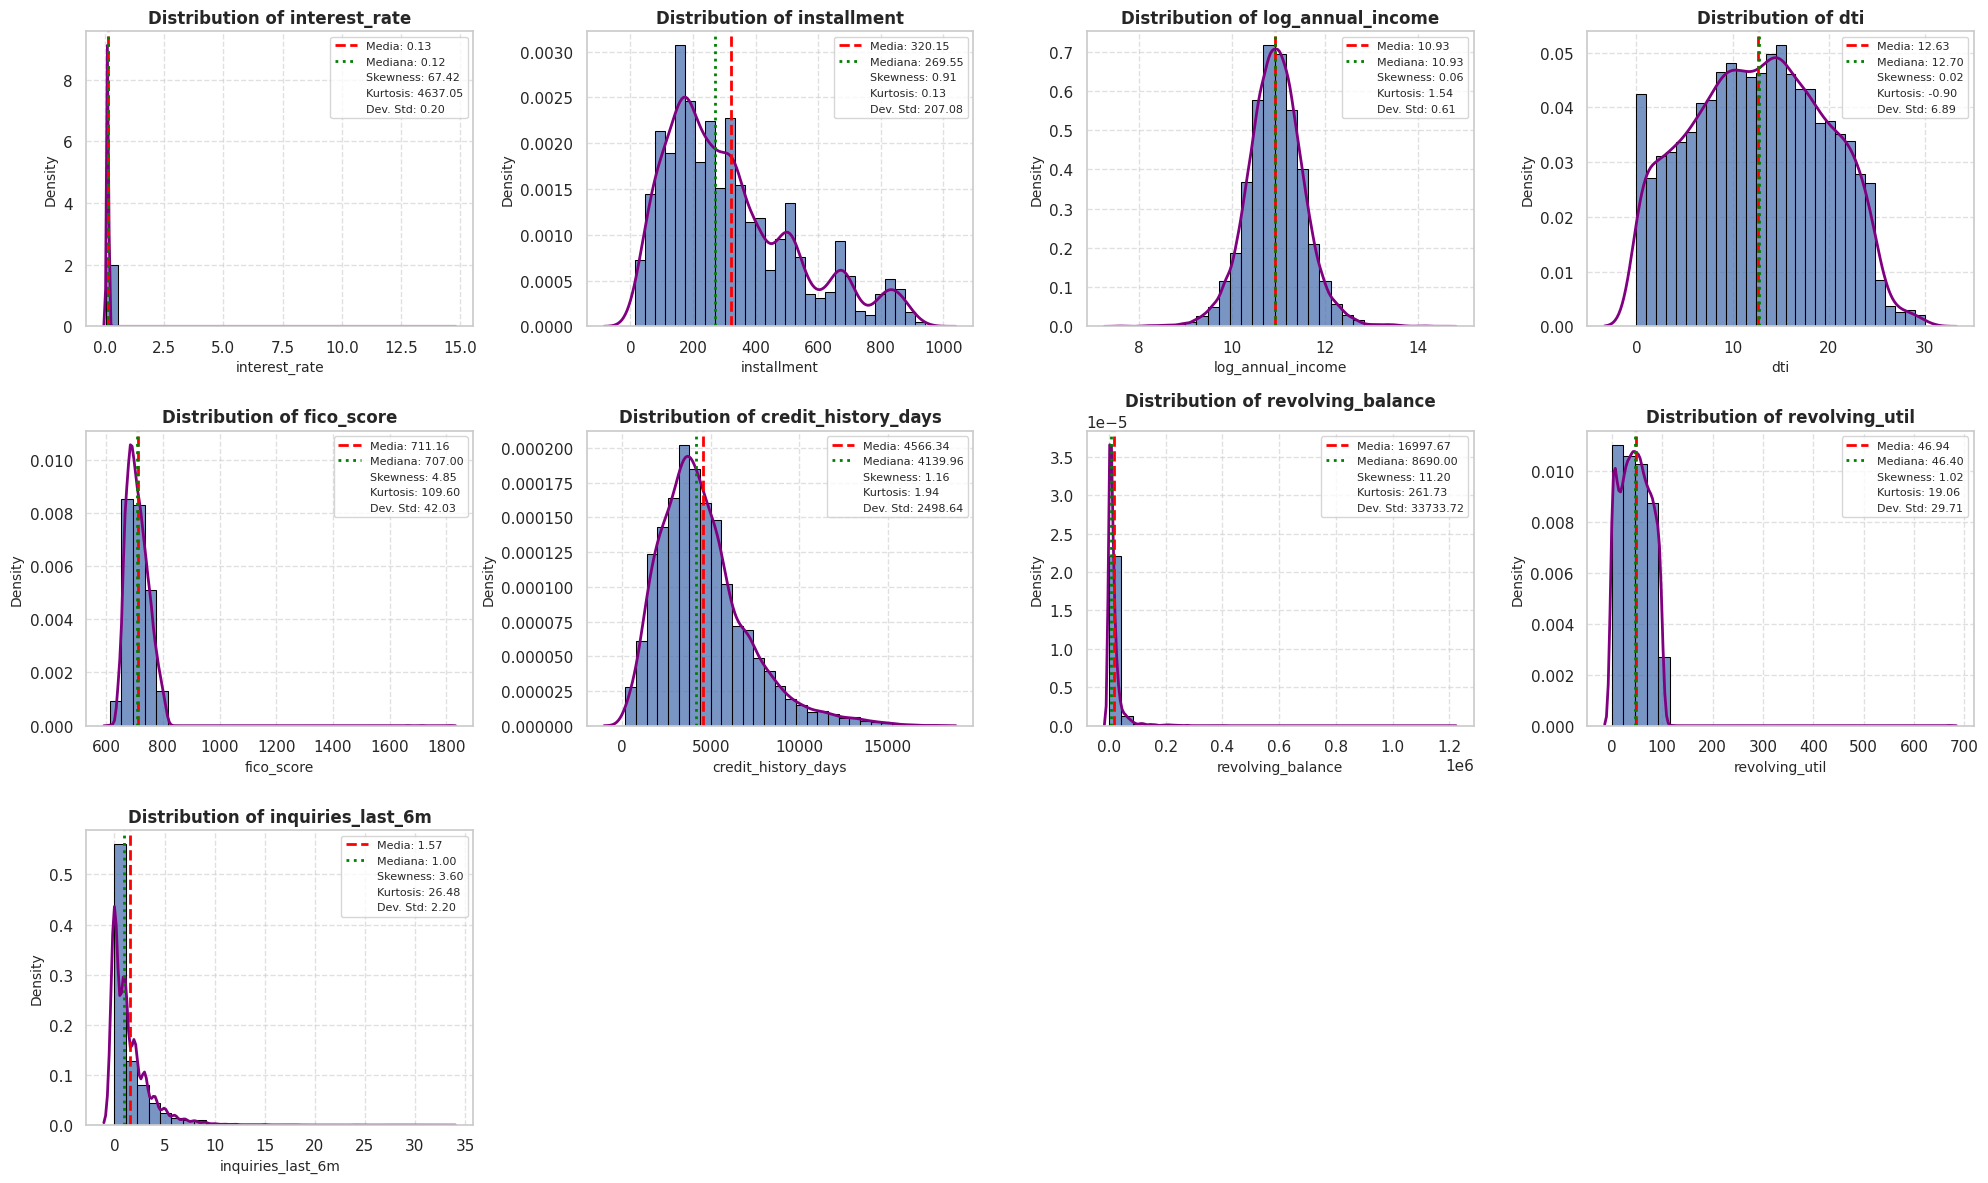

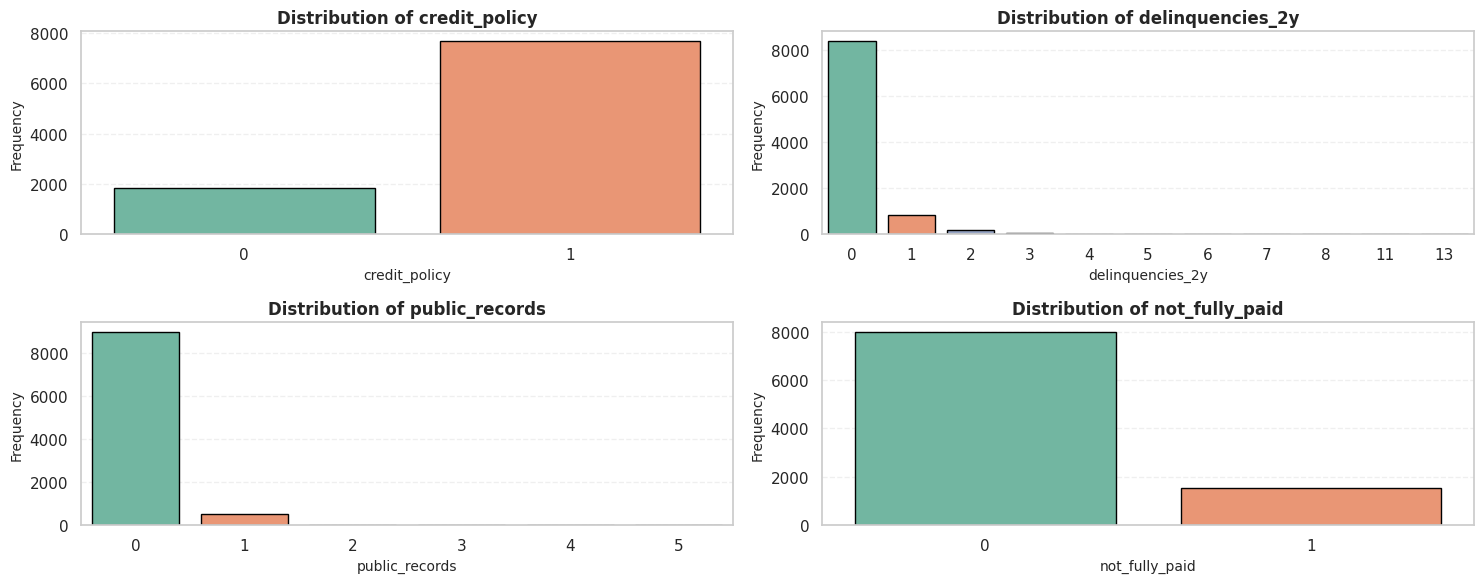

In [ ]:

# Separiamo colonne continue e discrete
numeric_cols = data.select_dtypes(include=[np.number]).columns.drop('customer_id')
discrete_cols = ['credit_policy', 'delinquencies_2y', 'public_records', 'not_fully_paid']
continuous_cols = [col for col in numeric_cols if col not in discrete_cols]

# Griglia per variabili CONTINUE (istogramma + KDE)
n_cols_cont = len(continuous_cols)
n_rows_cont = int(np.ceil(n_cols_cont / 4))

plt.figure(figsize=(20, n_rows_cont * 4))

for i, col in enumerate(continuous_cols):
    plt.subplot(n_rows_cont, 4, i+1)
    vals = data[col].dropna()
    bins = np.linspace(vals.min(), vals.max(), 30)

    ax = sns.histplot(vals, bins=bins, edgecolor="black", stat='density', kde=False)
    sns.kdeplot(vals, color='purple', lw=2, ax=ax)

    plt.title(f"Distribution of {col}", fontsize=12, fontweight='bold')

    # Calcoliamo le statistiche
    mean_val = vals.mean()
    median_val = vals.median()
    skew_val = vals.skew()
    kurt_val = vals.kurt()
    std_val = vals.std()

    # Linee verticali per media e mediana
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle=':', linewidth=2, label=f'Mediana: {median_val:.2f}')

    # Statistiche nella legenda
    plt.plot([], [], ' ', label=f'Skewness: {skew_val:.2f}')
    plt.plot([], [], ' ', label=f'Kurtosis: {kurt_val:.2f}')
    plt.plot([], [], ' ', label=f'Dev. Std: {std_val:.2f}')

    plt.legend(fontsize=8, loc='best')
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Density', fontsize=10)

plt.tight_layout()
plt.show()

# Griglia per variabili DISCRETE (bar plot)
n_cols_disc = len(discrete_cols)
n_rows_disc = int(np.ceil(n_cols_disc / 2))

plt.figure(figsize=(15, n_rows_disc * 3))

for i, col in enumerate(discrete_cols):
    plt.subplot(n_rows_disc, 2, i+1)
    sns.countplot(data=data, x=col, hue=col, palette='Set2', legend=False, edgecolor="black")
    plt.title(f"Distribution of {col}", fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

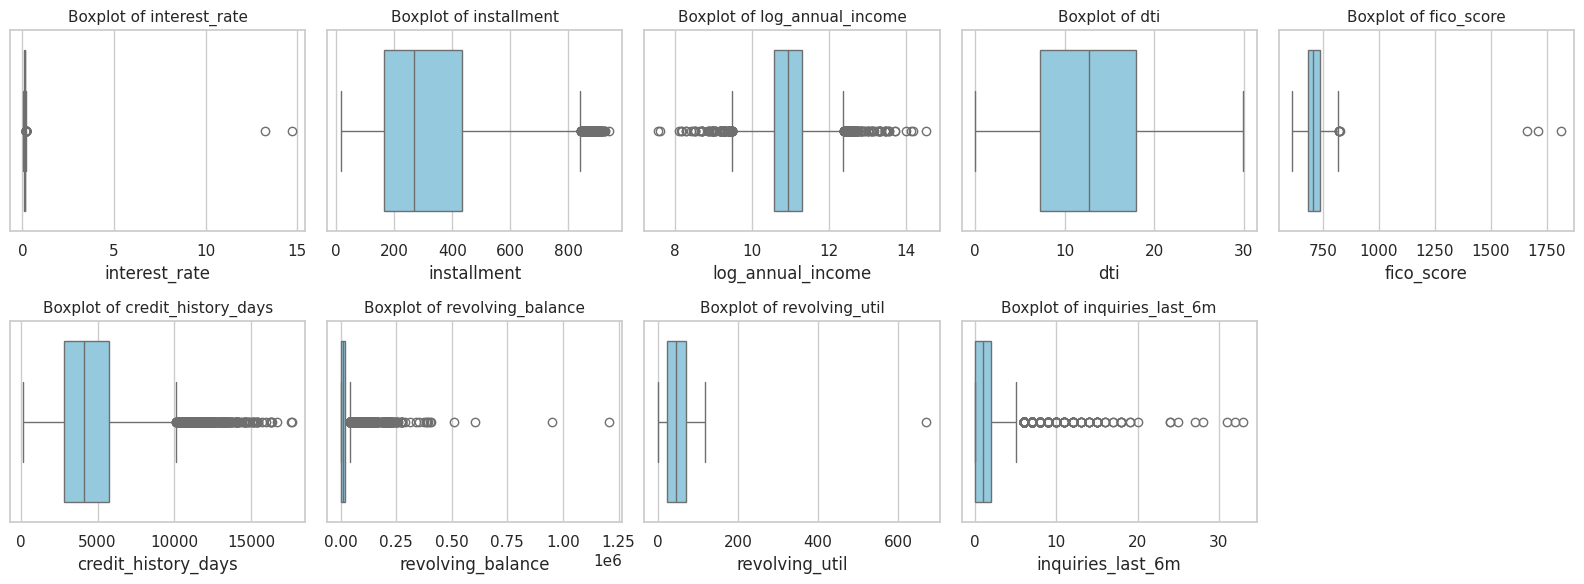

In [ ]:
plt.figure(figsize=(16, 6))
for idx, col in enumerate(continuous_cols):
    plt.subplot(2, int(np.ceil(len(continuous_cols)/2)), idx+1)
    sns.boxplot(data=data, x=col, color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=11)
    plt.xlabel(col)
plt.tight_layout()
plt.show()

<a id="interest-rate-dist"></a>
# ANALISI INTEREST_RATE

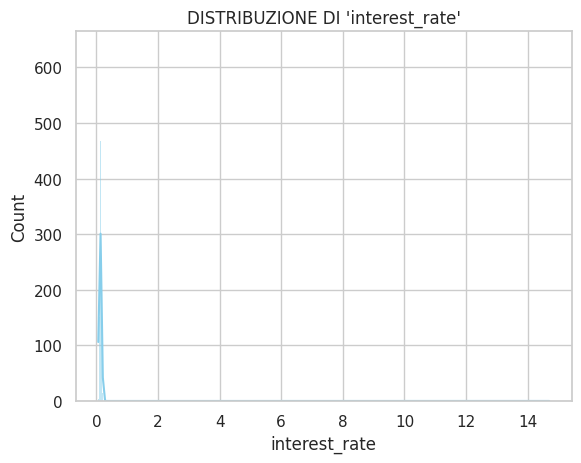

count    9508.000000
mean        0.125583
std         0.202949
min         0.060000
25%         0.103900
50%         0.122100
75%         0.140700
max        14.700000
Name: interest_rate, dtype: float64


In [ ]:
sns.histplot(data=data, x='interest_rate', kde=True, color='skyblue')
plt.title("DISTRIBUZIONE DI 'interest_rate'")
plt.show()

print(data['interest_rate'].describe())


<a id="interest-rate-outliers"></a>
#Visualizziamoli tramite BOXPLOT

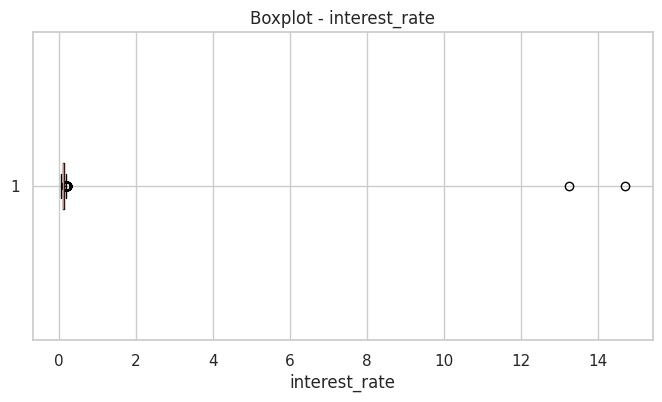

In [ ]:
plt.figure(figsize=(8,4))
plt.boxplot(data['interest_rate'], vert=False)
plt.title('Boxplot - interest_rate')
plt.xlabel('interest_rate')
plt.show()


#Abbiamo molti valori vicino lo zero e osserviamo come altri sono distaccati e arrivano fino a 14 il chè è strano.
#Per cui andiamo a calcolare gli intervalli.

In [ ]:
mask_decimal = data['interest_rate'] <= 1
n_corrected = mask_decimal.sum()

if n_corrected > 0:
    print(f"Conversione in corso: trovati {n_corrected} valori in scala decimale (<= 1).")
    data.loc[mask_decimal, 'interest_rate'] = data['interest_rate'] * 100
    print("Conversione completata: ora tutti i valori sono in scala percentuale (0-100).")
else:
    print("Nessun valore in scala decimale (<= 1) trovato. I dati sembrano già in percentuale.")

print("\nStatistiche post-conversione:")
print(data['interest_rate'].describe())

Q1 = data['interest_rate'].quantile(0.25)
Q3 = data['interest_rate'].quantile(0.75)
IQR = Q3 -Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Limite inferiore: {lower_bound:.4f}')
print(f'Limite superiore: {upper_bound:.4f}')

Conversione in corso: trovati 9506 valori in scala decimale (<= 1).
Conversione completata: ora tutti i valori sono in scala percentuale (0-100).

Statistiche post-conversione:
count    9508.000000
mean       12.267296
std         2.681129
min         6.000000
25%        10.390000
50%        12.210000
75%        14.070000
max        21.640000
Name: interest_rate, dtype: float64
Limite inferiore: 4.8700
Limite superiore: 19.5900


Abbiamo un tasso di interesse tra il 4.9% e 19.6% siamo in un intervallo 'normale'.
Ma poco fa abbiamo visto avere dei valori molto alti. Andiamo a controllare gli oulier

In [ ]:
lower_outlier = data[data['interest_rate'] < lower_bound]

# Filtrare gli upper outliers
upper_outlier = data[data['interest_rate'] > upper_bound]

print("Numero di lower outliers:", len(lower_outlier))
print("Numero di upper outliers:", len(upper_outlier))

Numero di lower outliers: 0
Numero di upper outliers: 51


In [ ]:
outliers = data[(data['interest_rate'] < lower_bound) | (data['interest_rate'] > upper_bound)]
print(f'NUMERO DI OUTLIERS TROVATI : {outliers.shape[0]}')

NUMERO DI OUTLIERS TROVATI : 51


In [ ]:
print("Esempi di outlier:")
print(outliers['interest_rate'].head())

Esempi di outlier:
2945    20.86
3713    20.11
3991    20.11
4064    19.79
4731    20.17
Name: interest_rate, dtype: float64


<a id="interest-rate-clean"></a>
Proviamo a pulirlo ovvero togliere gli outliers

In [ ]:
total_count = len(data)
outliers_count = len(outliers)

data_clean= data[(data['interest_rate'] >= lower_bound) & (data['interest_rate'] <= upper_bound)]
print(f'DIMENSIONE DATASET PULITO (SENZA OUTLIERS) : {data_clean.shape[0]} righe')

cleaned_count = len(data_clean)
removed_percentage = (outliers_count / total_count) * 100

print(f"Percentuale di outliers rimossi: {removed_percentage:.2f}%")

DIMENSIONE DATASET PULITO (SENZA OUTLIERS) : 9457 righe
Percentuale di outliers rimossi: 0.54%


Adesso abbiamo un dataset comunque molto grande ma più pulito!!                                                                                              Rimuovendo gli outliers andiamo a visualizzare in maniera più chiara  i nostri dati.

<a id="interest-rate-complete"></a>
VISUALIZZIAMO LE STATISTICHE DESCRITTIVE

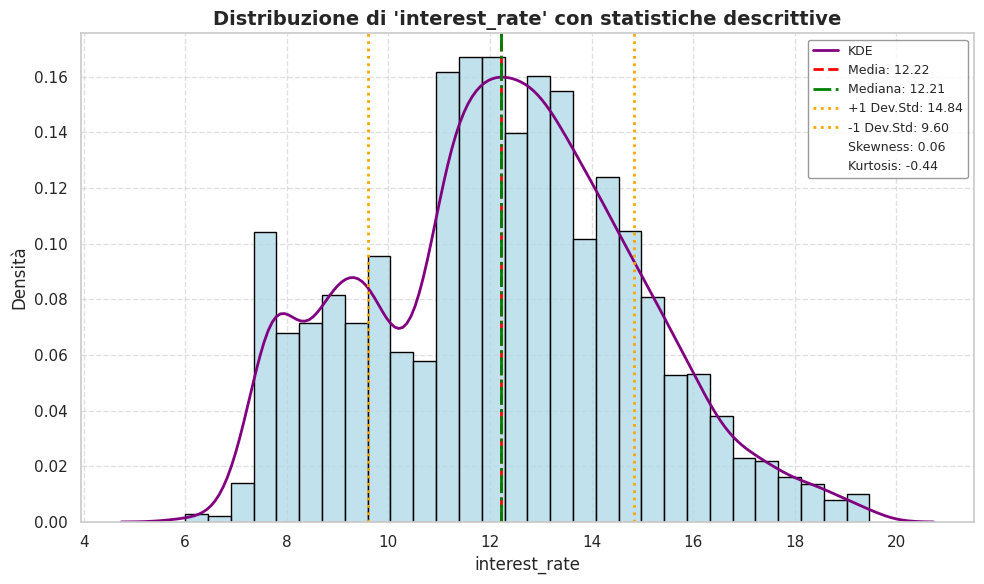

In [ ]:
colonna = 'interest_rate'

vals = data_clean[colonna].dropna()

mean_dc = vals.mean()
median_dc = vals.median()
skewness = vals.skew()
kurtosis = vals.kurt()
std_dc = vals.std()


plt.figure(figsize=(10, 6))

sns.histplot(vals, bins=30, color='lightblue', edgecolor='black', stat='density', kde=False)
sns.kdeplot(vals, color='purple', lw=2, label='KDE')

plt.axvline(mean_dc, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_dc:.2f}')
plt.axvline(median_dc, color='green', linestyle='-.', linewidth=2, label=f'Mediana: {median_dc:.2f}')
plt.axvline(mean_dc + std_dc, color='orange', linestyle=':', linewidth=2, label=f'+1 Dev.Std: {(mean_dc + std_dc):.2f}')
plt.axvline(mean_dc - std_dc, color='orange', linestyle=':', linewidth=2, label=f'-1 Dev.Std: {(mean_dc - std_dc):.2f}')

plt.plot([], [], ' ', label=f'Skewness: {skewness:.2f}')
plt.plot([], [], ' ', label=f'Kurtosis: {kurtosis:.2f}')

plt.title(f"Distribuzione di '{colonna}' con statistiche descrittive", fontsize=14, fontweight='bold')
plt.xlabel(colonna, fontsize=12)
plt.ylabel("Densità", fontsize=12)
plt.legend(fontsize=9, loc='best', frameon=True, facecolor='white', edgecolor='gray')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


Quindi il tasso di interesse (INTEREST RATE) medio nel nostro dataset è del 12,5% con la maggior parte dei valori compresi tra il 10% e il 14%
I tassi estremi oltre 20% sono rari, mentre valori sotto 6% rappresentano casi eccezionali o particolarmente favorevoli.

<a id="interest-rate-conclusioni"></a>
<font size="6">CONCLUSIONI</font>

<font size="4">PRIMA DEL CLEANING

Il mercato (o dataset) iniziale sembrava contenere casi estremi o anomali, che avrebbero potuto far pensare a condizioni di credito o rendimento completamente irrealistiche e quindi avrebbero falsato qualsiasi conclusione su costi del capitale o politiche monetarie.

La distribuzione iniziale del tasso di interesse era fortemente distorta verso destra (Skewness = 67.65) e molto appuntita (Kurtosis = 4669.57),ciò indica la presenza di pochi valori estremamente elevati (outlier), che spingono la media verso l'alto.
Il massimo di 14.7 (1.470%) è anomalo: in termini economici, un tasso di interesse così alto non è realistico per strumenti finanziari normali (es. prestiti, mutui o rendimenti su investimenti standard).
Si tratta di errori di inserimento o valori fuori scala.

DOPO IL CLEANING

Il mercato dei tassi d'interesse appare stabile e coerente.
In altre parole, non ci sono più estremi di rischio o casi anomali e il sistema sembra equilibrato e regolare.

Dopo la rimozione degli outlier, la distribuzione risulta centrata attorno al 12.2%, con una deviazione standard molto bassa (≈ 2.6%).
Skewness ≈ 0 e Kurtosis ≈ -0.45 → la distribuzione è simmetrica e leggermente platicurtica (piatta).
Questo suggerisce una maggiore omogeneità nei tassi dove la maggior parte si concentra in un intervallo ristretto (10%–14%).

</font>

<a id="installment-analisi"></a>
# ANALISI DI INSTALLMENT (RATA MENSILE)

<a id="installment-dist"></a>
Valori presenti

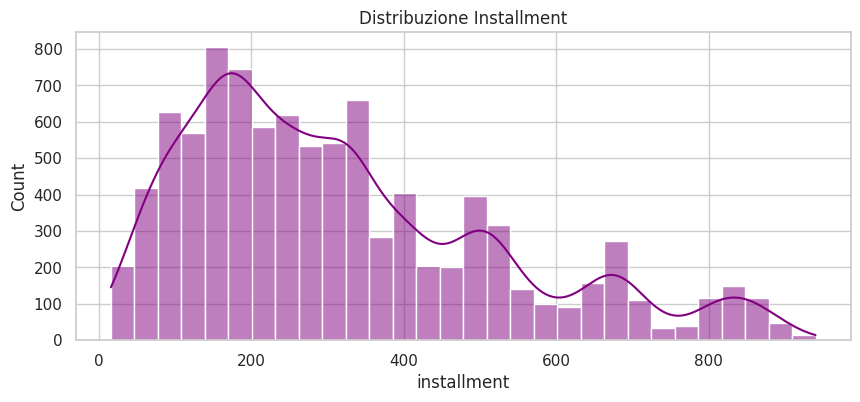

STATISTICHE DESCRITTIVE:

count    9508.000000
mean      320.152235
std       207.083521
min        15.670000
25%       164.020000
50%       269.545000
75%       435.232500
max       940.140000
Name: installment, dtype: float64


In [ ]:
plt.figure(figsize=(10,4))
sns.histplot(data['installment'], kde=True, bins = 30, color='purple')
plt.title('Distribuzione Installment')
plt.show()

print('STATISTICHE DESCRITTIVE:\n')
print(data['installment'].describe())

<a id="installment-boxplot"></a>
Osserviamolo con un boxplot

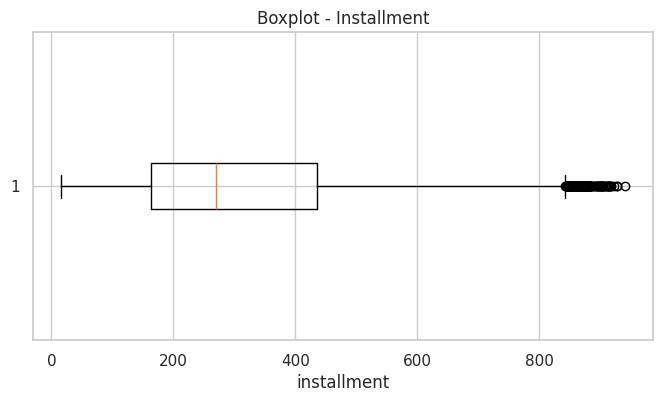

In [ ]:
plt.figure(figsize=(8,4))
plt.boxplot(data['installment'], vert=False)
plt.title('Boxplot - Installment')
plt.xlabel('installment')
plt.show()

Calcoliamo gli intervalli


In [ ]:
Q1 = data['installment'].quantile(0.25)
Q3 = data['installment'].quantile(0.75)
IQR = Q3 - Q1

lowerBound = Q1 - 1.5 * IQR
upperBound = Q3 + 1.5* IQR

print(f'Limite Inferiore: {lowerBound:.2f}')
print(f'Limite Superire: {upperBound:.2f}')



Limite Inferiore: -242.80
Limite Superire: 842.05


CALCOLIAMO GLI OUTLIERS

In [ ]:
# Filtrare i lower outliers classici (valori bassi estremi)
lower_outliers = data[data['installment'] < lowerBound]

# Filtrare gli upper outliers
upper_outliers = data[data['installment'] > upperBound]

print("Numero di lower outliers:", len(lower_outliers))
print("Numero di upper outliers:", len(upper_outliers))

Numero di lower outliers: 0
Numero di upper outliers: 193


In [ ]:
all_outliers = data[(data['installment'] < lowerBound) | (data['installment'] > upperBound)]

print("Numero totale di outlier :", all_outliers.shape[0])

Numero totale di outlier : 193


In [ ]:
all_outliers = data[(data['installment'] < lowerBound) | (data['installment'] > upperBound)]
print("Esempi di outlier:")
print(all_outliers[['installment','dti', 'customer_id']].head())

Esempi di outlier:
     installment    dti  customer_id
237       859.07  20.79        10238
249       842.47  12.81        10250
271       862.97   5.79        10272
275       851.41  19.78        10276
322       876.83  18.08        10323


Come possiamo notare troviamo come outliers anche rate da 842.47 che si discostano poco dal valore max!!
 Definire queste rate outliers non è una buona cosa perchè nella realtà potrebbero anche essere rate di individui che pagano tanto.(vedremo con analisi multivariata)

**CALCOLIAMO SKEWNESS E CURTOSI**

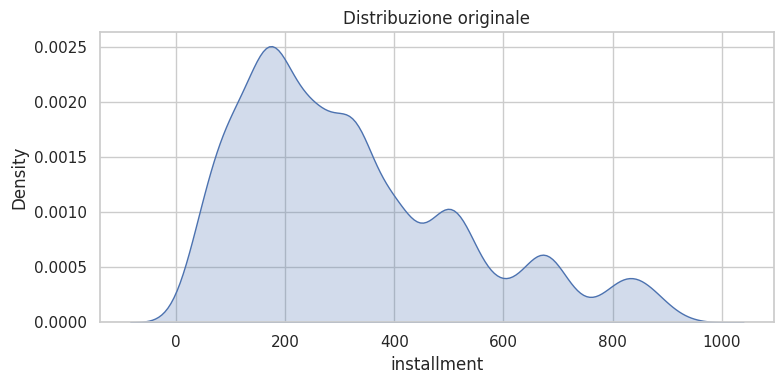


INSTALLMENT
Asimmetria_Skewness: 0.91 | Kurtosis: 0.13


In [ ]:
sns.set(style="whitegrid")

skew = data['installment'].skew()
kurt = data['installment'].kurt()


fig, axes = plt.subplots(1, 1, figsize=(8, 4))
sns.kdeplot(data['installment'], ax = axes, fill=True)
axes.set_title('Distribuzione originale')


plt.tight_layout()
plt.show()

for col in ['installment']:
    print(f"\n{col.upper()}")
    print(f"Asimmetria_Skewness: {data[col].skew():.2f} | Kurtosis: {data[col].kurt():.2f}")



Per quanto riguarda l'asimmetria abbiamo una simmetria positiva, ma con una distribuzine sbilanciata verso destra.

Per quanto riguarda Curtosi invece la distribuzione è comunque simile a una normale ma con una tendenza ad avere valori più estremi.

<font size="6">Credit_history_days</font>

Credit_history_days" (giorni di storia creditizia) è una variabile numerica che, in un contesto di analisi del credito o del rischio finanziario, indica la durata totale della storia creditizia di un individuo o di un'entità, misurata in giorni.

Significato: Rappresenta da quanti giorni la persona (o l'entità) ha attivamente utilizzato o avuto accesso a prodotti di credito (come prestiti, carte di credito, mutui, ecc.).

Importanza: Una storia creditizia più lunga è generalmente considerata un fattore positivo, poiché offre ai finanziatori più dati e tempo per valutare l'affidabilità e la coerenza del comportamento di rimborso del debitore.

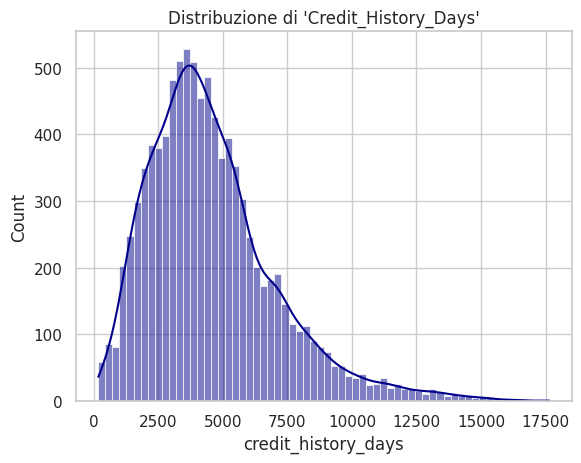

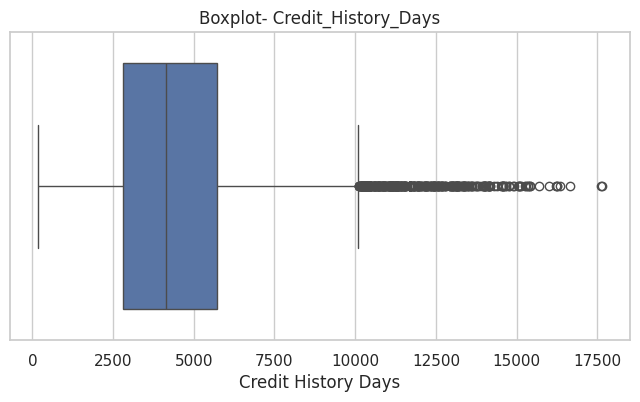

count     9508.000000
mean      4566.344881
std       2498.641022
min        180.041667
25%       2820.000000
50%       4139.958333
75%       5730.041667
max      17639.958330
Name: credit_history_days, dtype: float64

Skewness: 1.1584
Kurtosis: 1.9393


In [ ]:
sns.histplot (data = data, x ='credit_history_days', kde = True, color = 'darkblue')
plt.title("Distribuzione di 'Credit_History_Days'")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x = data['credit_history_days'])
plt.title('Boxplot- Credit_History_Days')
plt.xlabel('Credit History Days')
plt.show()

print(data['credit_history_days'].describe())

print(f"\nSkewness: {data['credit_history_days'].skew():.4f}")
print(f"Kurtosis: {data['credit_history_days'].kurt():.4f}")


**Convertiamo da giorni in anni!**

Osservando banche, credit bureau, finanza consumer:

Anni di storia creditizia:

**0–5 anni**:	Molto comune

**5–20 anni**:	Normale

**20–35 anni**:	Comune negli adulti più anziani

**35–45 anni**:	Meno comune ma realistico

**45–55 anni**:	Possibile solo per persone molto anziane (60–75 anni)

**>55 anni**:	Raro → da verificare

**>65 anni**:	Quasi impossibile → probabilmente errore o anomalia

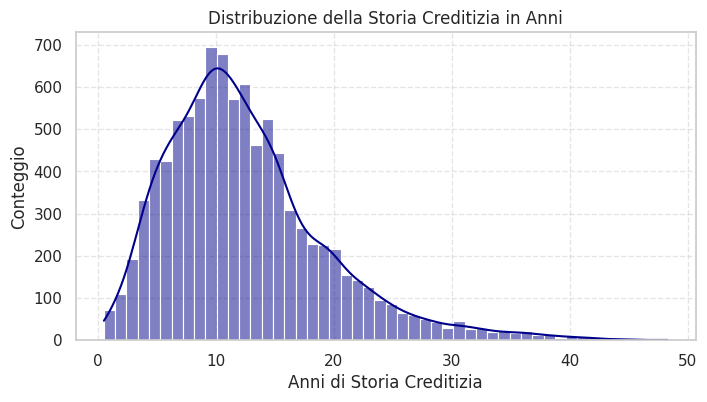

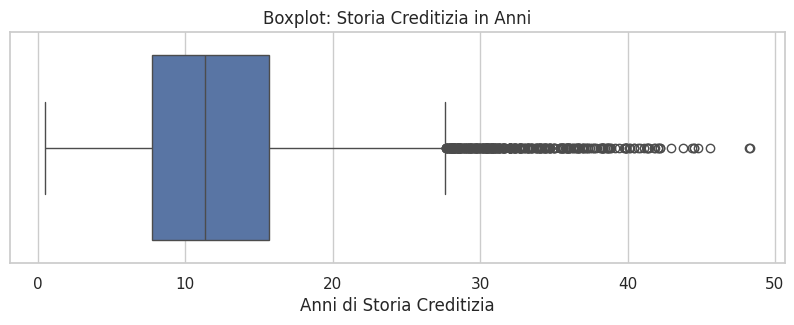

count    9508.000000
mean       12.501971
std         6.840906
min         0.492927
25%         7.720739
50%        11.334588
75%        15.687999
max        48.295574
Name: credit_history_years, dtype: float64

Skewness: 1.1584
Kurtosis: 1.9393


In [ ]:
data['credit_history_years'] = data['credit_history_days'] / 365.25

plt.figure(figsize=(8,4))
sns.histplot(data['credit_history_years'], kde=True, bins=50, color = 'darkblue')
plt.title('Distribuzione della Storia Creditizia in Anni')
plt.xlabel('Anni di Storia Creditizia')
plt.ylabel('Conteggio')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(10,3))
sns.boxplot(x=data['credit_history_years'])
plt.title('Boxplot: Storia Creditizia in Anni')
plt.xlabel('Anni di Storia Creditizia')
plt.show()

print(data['credit_history_years'].describe())

print(f"\nSkewness: {data['credit_history_days'].skew():.4f}")
print(f"Kurtosis: {data['credit_history_days'].kurt():.4f}")

In [ ]:
Q1 = data['credit_history_years'].quantile(0.25)
Q3 = data['credit_history_years'].quantile(0.75)
IQR = Q3 - Q1

lower_bound_chd = Q1 - 1.5 * IQR
upper_bound_chd = Q3 + 1.5 * IQR

print(f'Limite Inferiore: {lower_bound_chd:.4f}')
print(f'Limite Superiore: {upper_bound_chd:.4f}')

Limite Inferiore: -4.2302
Limite Superiore: 27.6389


Calcolando i limiti vediamo che il limite superiore è quasi 28 anni. Se consideriamo i dati reali , vogliamo considerare outliers solo quelli maggiori di 45 anni.

In [ ]:
upper_limit = 45
outliers = data[data['credit_history_years'] > upper_limit]
df_clean = data[data['credit_history_years'] <= upper_limit]

print('Numero di outlier sopra i 45 anni:', len(outliers))

Numero di outlier sopra i 45 anni: 3


In [ ]:
print('Outliers nel dataset:')
print(outliers['credit_history_years'].head())

Outliers nel dataset:
5801    45.590691
7553    48.229979
8430    48.295574
Name: credit_history_years, dtype: float64


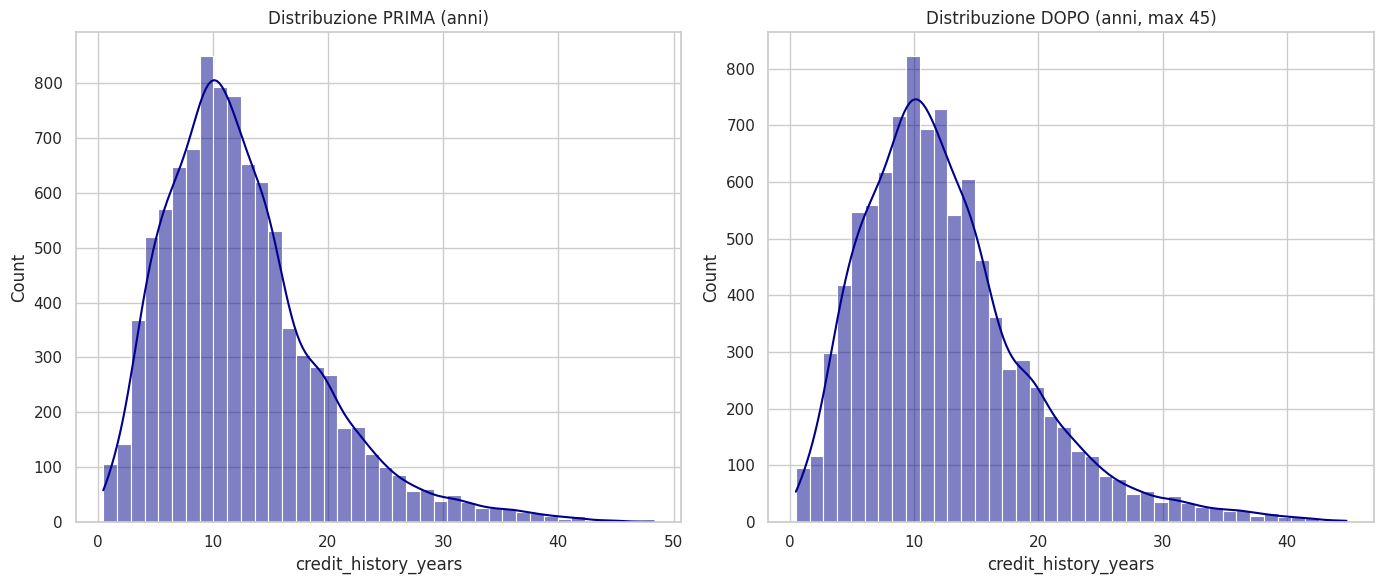

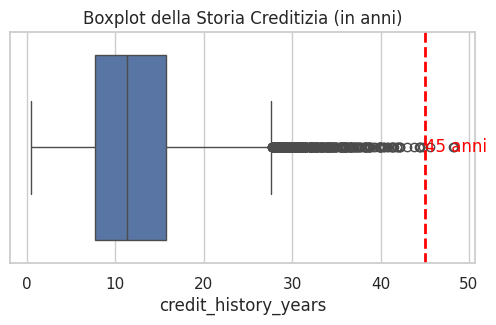

count    9505.000000
mean       12.490965
std         6.813834
min         0.492927
25%         7.720739
50%        11.334588
75%        15.687885
max        44.763860
Name: credit_history_years, dtype: float64

Skewness: 1.1350
Kurtosis: 1.8088


In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(data["credit_history_years"], kde=True, bins=40, color = 'darkblue')
plt.title("Distribuzione PRIMA (anni)")
plt.xlabel("credit_history_years")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.histplot(df_clean["credit_history_years"], kde=True, bins=40, color = 'darkblue')
plt.title("Distribuzione DOPO (anni, max 45)")
plt.xlabel("credit_history_years")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
sns.boxplot(x=data["credit_history_years"])
plt.title("Boxplot della Storia Creditizia (in anni)")


plt.axvline(x=45, color='red', linestyle='--', linewidth=2)
plt.text(45, 0.02, "45 anni", color='red')

plt.xlabel("credit_history_years")
plt.show()


print(df_clean['credit_history_years'].describe())

print(f"\nSkewness: {df_clean['credit_history_years'].skew():.4f}")
print(f"Kurtosis: {df_clean['credit_history_years'].kurt():.4f}")

Rispetto a prima non c'è una riduzione massiccia perchè abbiamo tolo solo lo 0.03% e rimuovere solo 3 valori non può cambiare drasticamente la forma della distribuzione ma vabene così perchè nella realtà è normale una coda lunga.

### Statistiche per Categoria

Calcoliamo media, mediana e deviazione standard del FICO Score per ogni categoria.

---
<a id="fico-score"></a>
## Analisi FICO Score

Il FICO Score misura l'affidabilità creditizia di un cliente (range 300-850). In questa sezione rispondiamo alla domanda: **qual è il FICO Score medio dei richiedenti?**

### Categorie FICO Score

Suddividiamo i punteggi in categorie standard per facilitare l'interpretazione:

- **300-579**: Very Poor (Pessimo)
- **580-669**: Fair (Discreto)
- **670-739**: Good (Buono)
- **740-799**: Very Good (Molto Buono)
- **800-850**: Exceptional (Eccellente)

![FICO Score Categories](images/fico_ranges.jpg)

Questa classificazione segue gli standard FICO ufficiali e ci permette di capire la distribuzione qualitativa del rischio nel nostro portafoglio prestiti.

### Distribuzione FICO Score

**Dashboard completa:** istogramma, boxplot e bar chart delle categorie

In [ ]:
print("=== STATISTICHE FICO SCORE ===")
print(data['fico_score'].describe())
print(f"\nSkewness: {data['fico_score'].skew():.4f}")
print(f"Kurtosis: {data['fico_score'].kurt():.4f}")

=== STATISTICHE FICO SCORE ===
count    9508.000000
mean      711.155974
std        42.033425
min       612.000000
25%       682.000000
50%       707.000000
75%       737.000000
max      1812.000000
Name: fico_score, dtype: float64

Skewness: 4.8531
Kurtosis: 109.6038


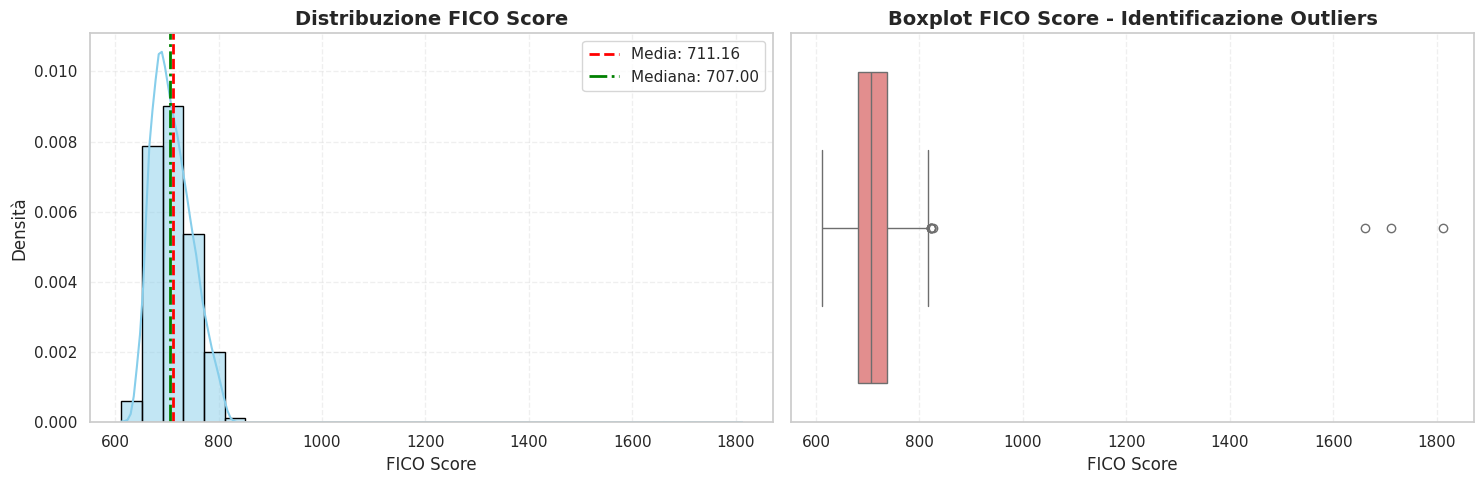

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Istogramma + KDE
ax1 = axes[0]
sns.histplot(data['fico_score'], bins=30, kde=True, color='skyblue', edgecolor='black', ax=ax1, stat='density')
ax1.axvline(data['fico_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {data["fico_score"].mean():.2f}')
ax1.axvline(data['fico_score'].median(), color='green', linestyle='-.', linewidth=2, label=f'Mediana: {data["fico_score"].median():.2f}')
ax1.set_title('Distribuzione FICO Score', fontsize=14, fontweight='bold')
ax1.set_xlabel('FICO Score', fontsize=12)
ax1.set_ylabel('Densità', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.3)

# Boxplot
ax2 = axes[1]
sns.boxplot(x=data['fico_score'], color='lightcoral', ax=ax2)
ax2.set_title('Boxplot FICO Score - Identificazione Outliers', fontsize=14, fontweight='bold')
ax2.set_xlabel('FICO Score', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [ ]:
# Identificazione outliers per FICO Score
Q1_fico = data['fico_score'].quantile(0.25)
Q3_fico = data['fico_score'].quantile(0.75)
IQR_fico = Q3_fico - Q1_fico

lower_bound_fico = Q1_fico - 1.5 * IQR_fico
upper_bound_fico = 851

print(f'Limite inferiore: {lower_bound_fico:.2f}')
print(f'Limite superiore: {upper_bound_fico:.2f}')

outliers_fico = data[(data['fico_score'] < lower_bound_fico) | (data['fico_score'] > upper_bound_fico)]
print(f'\nNUMERO DI OUTLIERS TROVATI: {outliers_fico.shape[0]}')
print(f'Percentuale di outliers: {(outliers_fico.shape[0] / len(data)) * 100:.2f}%')
print(f'Valore massimo FICO Score: {data["fico_score"].max()}')

# Rimozione degli outlier
total_count_fico = len(data)
outliers_count_fico = len(outliers_fico)

print(f'\n{"="*60}')
print(f'PULIZIA FICO SCORE')
print(f'{"="*60}')
print(f'Dimensione dataset PRIMA della pulizia: {total_count_fico} righe')

data = data[(data['fico_score'] >= lower_bound_fico) & (data['fico_score'] <= upper_bound_fico)]

print(f'Dimensione dataset DOPO la pulizia: {len(data)} righe')
print(f'Righe rimosse: {outliers_count_fico}')
print(f'Percentuale rimossa: {(outliers_count_fico / total_count_fico) * 100:.2f}%')

# Nuove statistiche dopo pulizia
print(f'\n{"="*60}')
print("STATISTICHE FICO SCORE DOPO PULIZIA")
print(f'{"="*60}')
print(data['fico_score'].describe())
print(f"\nSkewness: {data['fico_score'].skew():.4f}")
print(f"Kurtosis: {data['fico_score'].kurt():.4f}")
print(f'{"="*60}')
print(data['fico_score'].max())

Limite inferiore: 599.50
Limite superiore: 851.00

NUMERO DI OUTLIERS TROVATI: 3
Percentuale di outliers: 0.03%
Valore massimo FICO Score: 1812

PULIZIA FICO SCORE
Dimensione dataset PRIMA della pulizia: 9508 righe
Dimensione dataset DOPO la pulizia: 9505 righe
Righe rimosse: 3
Percentuale rimossa: 0.03%

STATISTICHE FICO SCORE DOPO PULIZIA
count    9505.000000
mean      710.834824
std        37.937155
min       612.000000
25%       682.000000
50%       707.000000
75%       737.000000
max       827.000000
Name: fico_score, dtype: float64

Skewness: 0.4678
Kurtosis: -0.4289
827


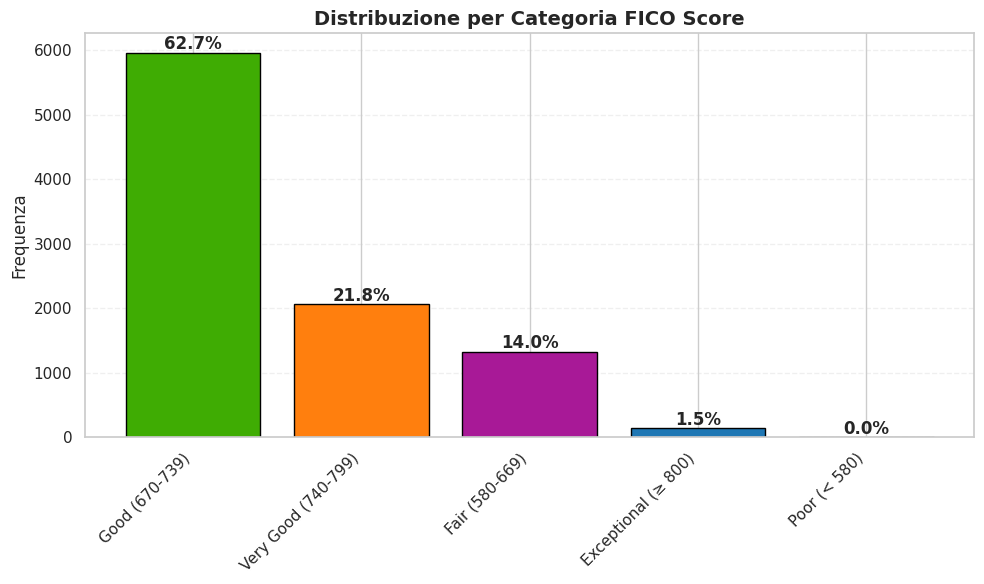


=== DISTRIBUZIONE PER CATEGORIA ===
Good (670-739): 5963 (62.74%)
Very Good (740-799): 2071 (21.79%)
Fair (580-669): 1331 (14.00%)
Exceptional (≥ 800): 140 (1.47%)
Poor (< 580): 0 (0.00%)


In [ ]:
def classify_fico(score):
    if score < 580:
        return 'Poor (< 580)'
    elif score < 670:
        return 'Fair (580-669)'
    elif score < 740:
        return 'Good (670-739)'
    elif score < 800:
        return 'Very Good (740-799)'
    else:
        return 'Exceptional (≥ 800)'

data['fico_category'] = data['fico_score'].apply(classify_fico)

category_order = ['Poor (< 580)','Fair (580-669)', 'Good (670-739)', 'Very Good (740-799)', 'Exceptional (≥ 800)']
data['fico_category'] = pd.Categorical(data['fico_category'], categories=category_order, ordered=True)

plt.figure(figsize=(10, 6))

fico_counts = data['fico_category'].value_counts()
colors = ['#3fac03', '#ff7f0e', "#a81997", '#1f77b4', '#9467bd']
plt.bar(range(len(fico_counts)), fico_counts.values, color=colors, edgecolor='black')
plt.xticks(range(len(fico_counts)), fico_counts.index, rotation=45, ha='right')
plt.title('Distribuzione per Categoria FICO Score', fontsize=14, fontweight='bold')
plt.ylabel('Frequenza', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Percentuali
for i, (cat, count) in enumerate(fico_counts.items()):
    pct = (count / len(data)) * 100
    plt.text(i, count + 50, f'{pct:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== DISTRIBUZIONE PER CATEGORIA ===")
for cat, count in fico_counts.items():
    print(f"{cat}: {count} ({(count/len(data))*100:.2f}%)")

---
<a id="purpose-analisi"></a>
## Analisi Purpose

**Quali sono gli scopi più comuni per cui le persone richiedono prestiti?**


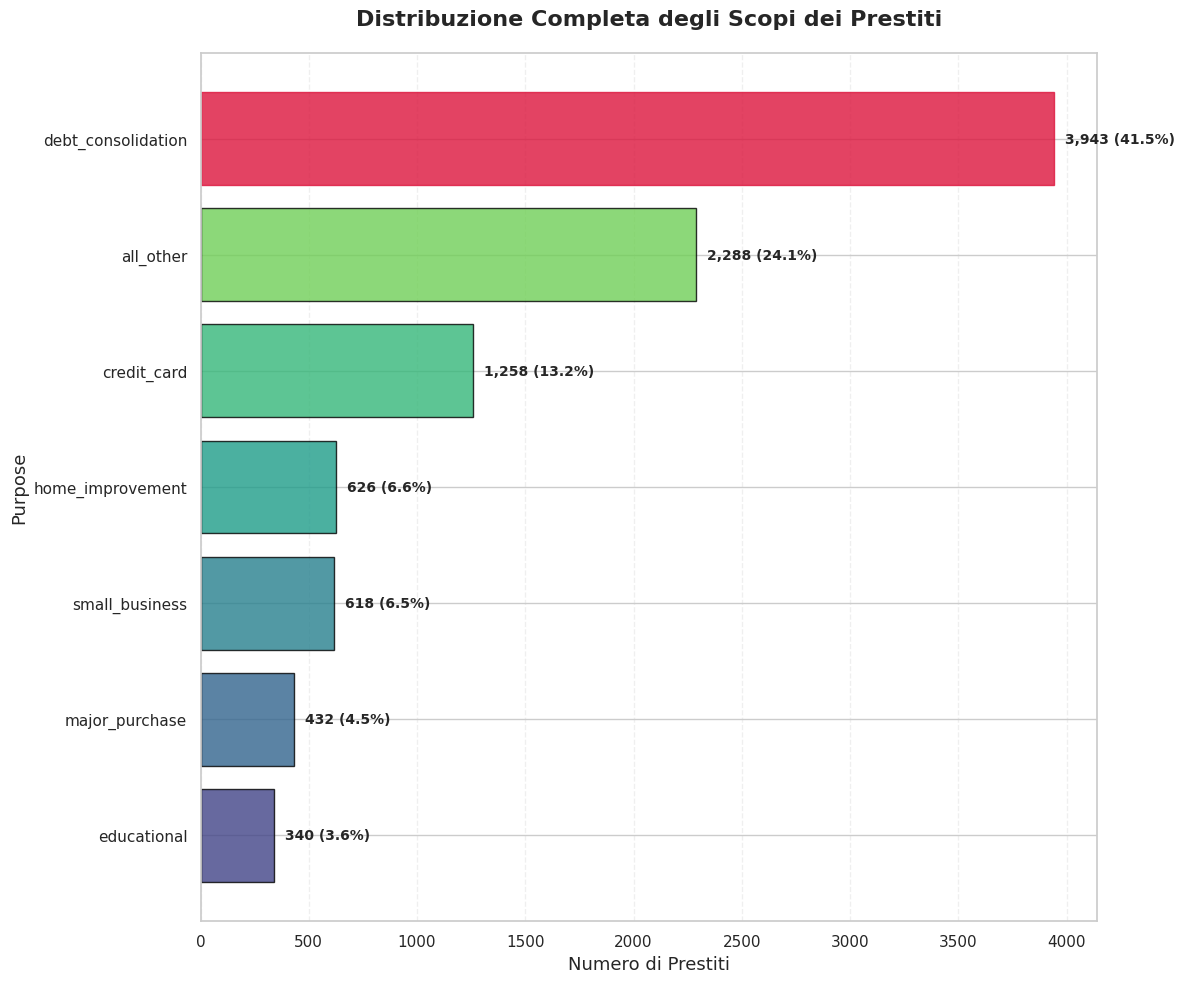


                    STATISTICHE PURPOSE
Purpose                               Count      Percentage
----------------------------------------------------------------------
debt_consolidation                    3,943          41.48%
all_other                             2,288          24.07%
credit_card                           1,258          13.24%
home_improvement                        626           6.59%
small_business                          618           6.50%
major_purchase                          432           4.54%
educational                             340           3.58%
TOTALE                                9,505         100.00%

Numero totale di categorie:         7
Categoria più frequente:            debt_consolidation (3,943 prestiti)
Categoria meno frequente:           educational (340 prestiti)


In [ ]:

purpose_counts = data['purpose'].value_counts()
purpose_pct = (purpose_counts / len(data) * 100)

purpose_counts_sorted = purpose_counts.sort_values()

fig, ax = plt.subplots(figsize=(12, 10))

colors_gradient = plt.cm.viridis(np.linspace(0.2, 0.9, len(purpose_counts_sorted)))

bars = ax.barh(range(len(purpose_counts_sorted)),
               purpose_counts_sorted.values,
               color=colors_gradient,
               edgecolor='black',
               alpha=0.8)

# Colora in rosso la barra più alta
max_idx = np.argmax(purpose_counts_sorted.values)
bars[max_idx].set_color('crimson')

# Aggiungi le percentuali alla fine di ogni barra
for i, (purpose, count) in enumerate(purpose_counts_sorted.items()):
    pct = (count / len(data)) * 100
    ax.text(count + 50, i, f'{count:,} ({pct:.1f}%)',
            va='center', fontweight='bold', fontsize=10)

# Imposta le etichette sull'asse Y
ax.set_yticks(range(len(purpose_counts_sorted)))
ax.set_yticklabels(purpose_counts_sorted.index, fontsize=11)

ax.set_title('Distribuzione Completa degli Scopi dei Prestiti',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Numero di Prestiti', fontsize=13)
ax.set_ylabel('Purpose', fontsize=13)

ax.grid(True, linestyle='--', alpha=0.3, axis='x')


plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(" "*20 + "STATISTICHE PURPOSE")
print("="*70)
print(f"{'Purpose':<30} {'Count':>12} {'Percentage':>15}")
print("-"*70)
for purpose, count in purpose_counts.items():
    pct = (count / len(data)) * 100
    print(f"{purpose:<30} {count:>12,} {pct:>14.2f}%")
print("="*70)
print(f"{'TOTALE':<30} {len(data):>12,} {100.0:>14.2f}%")
print("="*70)

# Statistiche aggiuntive
print(f"\n{'Numero totale di categorie:':<35} {len(purpose_counts)}")
print(f"{'Categoria più frequente:':<35} {purpose_counts.index[0]} ({purpose_counts.iloc[0]:,} prestiti)")
print(f"{'Categoria meno frequente:':<35} {purpose_counts.index[-1]} ({purpose_counts.iloc[-1]:,} prestiti)")

---
<a id="annual-income"></a>
# Analizziamo il profilo generale dei redditi dei clienti, DA CONTINUARE

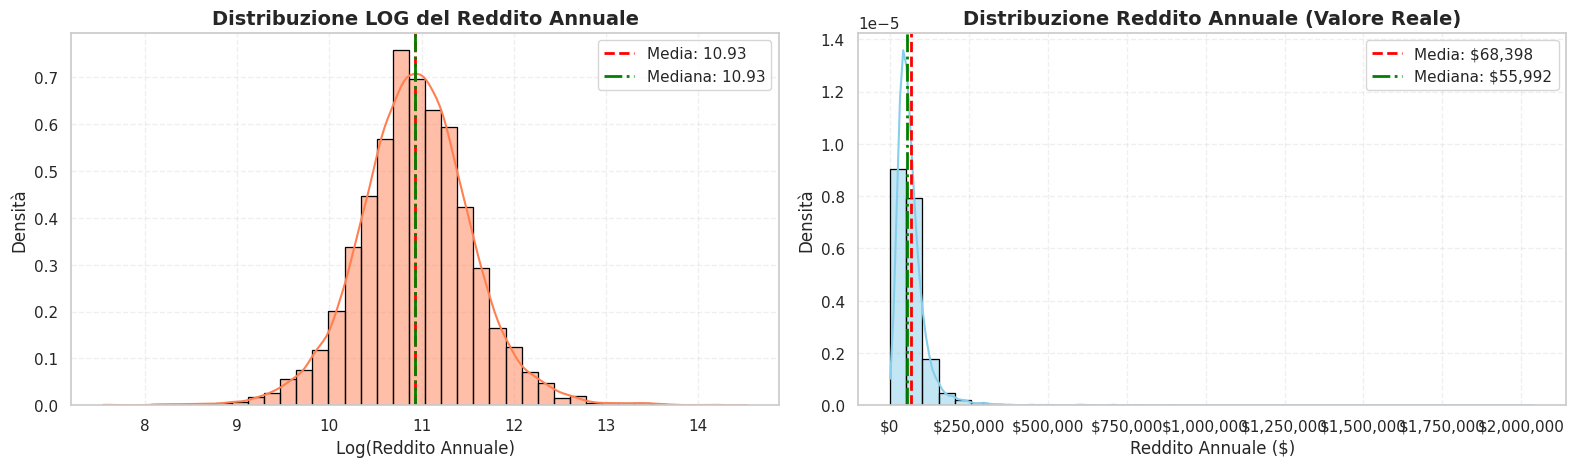


Skewness (Log): 0.0640
Skewness (Reale): 9.6758
min 1896.0000003508226
max 2039784.004362027
mean 68397.52192401636
std 61134.666732547186


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
data['annual_income'] = np.exp(data['log_annual_income'])

ax1 = axes[0]
sns.histplot(data['log_annual_income'], bins=40, kde=True, color='coral', edgecolor='black', ax=ax1, stat='density')
ax1.axvline(data['log_annual_income'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: {data["log_annual_income"].mean():.2f}')
ax1.axvline(data['log_annual_income'].median(), color='green', linestyle='-.', linewidth=2,
            label=f'Mediana: {data["log_annual_income"].median():.2f}')
ax1.set_title('Distribuzione LOG del Reddito Annuale', fontsize=14, fontweight='bold')
ax1.set_xlabel('Log(Reddito Annuale)', fontsize=12)
ax1.set_ylabel('Densità', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.3)


ax2 = axes[1]
sns.histplot(data['annual_income'], bins=40, kde=True, color='skyblue', edgecolor='black', ax=ax2, stat='density')
ax2.axvline(data['annual_income'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: ${data["annual_income"].mean():,.0f}')
ax2.axvline(data['annual_income'].median(), color='green', linestyle='-.', linewidth=2,
            label=f'Mediana: ${data["annual_income"].median():,.0f}')
ax2.set_title('Distribuzione Reddito Annuale (Valore Reale)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Reddito Annuale ($)', fontsize=12)
ax2.set_ylabel('Densità', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.3)


ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

print(f"\nSkewness (Log): {data['log_annual_income'].skew():.4f}")
print(f"Skewness (Reale): {data['annual_income'].skew():.4f}")

data['annual_income'].describe()
print("min", data['annual_income'].min())
print("max", data['annual_income'].max())
print("mean", data['annual_income'].mean())
print("std", data['annual_income'].std())

<a id="dti-analisi"></a>
# Analisi Completa della  DTI

## Cos'è il DTI?

Il **Debt-to-Income Ratio (DTI)** è un indicatore fondamentale nel settore del credito che misura il rapporto tra i debiti mensili totali di un individuo e il suo reddito mensile lordo.

### Formula:
$$\text{DTI} = \frac{\text{Pagamenti Debiti Mensili Totali}}{\text{Reddito Mensile Lordo}} \times 100$$


Un DTI elevato indica che una persona sta già utilizzando gran parte del proprio reddito per pagare debiti esistenti, riducendo la capacità di onorare nuovi prestiti.

##  Statistiche Descrittive DTI

In [ ]:
data_clean_dti = data[(data['dti'] >= lower_bound) & (data['dti'] <= upper_bound)]

print("="*60)
print("CONFRONTO STATISTICHE DTI")
print("="*60)

stats_comparison = pd.DataFrame({
    'Metrica': ['Count', 'Media', 'Mediana', 'Dev. Std', 'Min', 'Q1', 'Q3', 'Max', 'Skewness', 'Kurtosis'],
    'Con Outliers': [
        len(data),
        data['dti'].mean(),
        data['dti'].median(),
        data['dti'].std(),
        data['dti'].min(),
        data['dti'].quantile(0.25),
        data['dti'].quantile(0.75),
        data['dti'].max(),
        data['dti'].skew(),
        data['dti'].kurtosis()
    ],
    'Senza Outliers': [
        len(data_clean_dti),
        data_clean_dti['dti'].mean(),
        data_clean_dti['dti'].median(),
        data_clean_dti['dti'].std(),
        data_clean_dti['dti'].min(),
        data_clean_dti['dti'].quantile(0.25),
        data_clean_dti['dti'].quantile(0.75),
        data_clean_dti['dti'].max(),
        data_clean_dti['dti'].skew(),
        data_clean_dti['dti'].kurtosis()
    ]
})

stats_comparison['Variazione (%)'] = ((stats_comparison['Senza Outliers'] - stats_comparison['Con Outliers']) /
                                       stats_comparison['Con Outliers'] * 100).round(2)

print("\n" + stats_comparison.to_string(index=False))
print("\n" + "="*60)

CONFRONTO STATISTICHE DTI

 Metrica  Con Outliers  Senza Outliers  Variazione (%)
   Count   9505.000000     6190.000000          -34.88
   Media     12.631811       12.336247           -2.34
 Mediana     12.700000       12.420000           -2.20
Dev. Std      6.886351        4.075753          -40.81
     Min      0.000000        4.880000             inf
      Q1      7.230000        8.932500           23.55
      Q3     18.000000       15.720000          -12.67
     Max     29.960000       19.580000          -34.65
Skewness      0.020727       -0.038604         -286.25
Kurtosis     -0.902086       -1.123320           24.52



## Distribuzione del DTI

/tmp/ipython-input-4052354678.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(['DTI'])


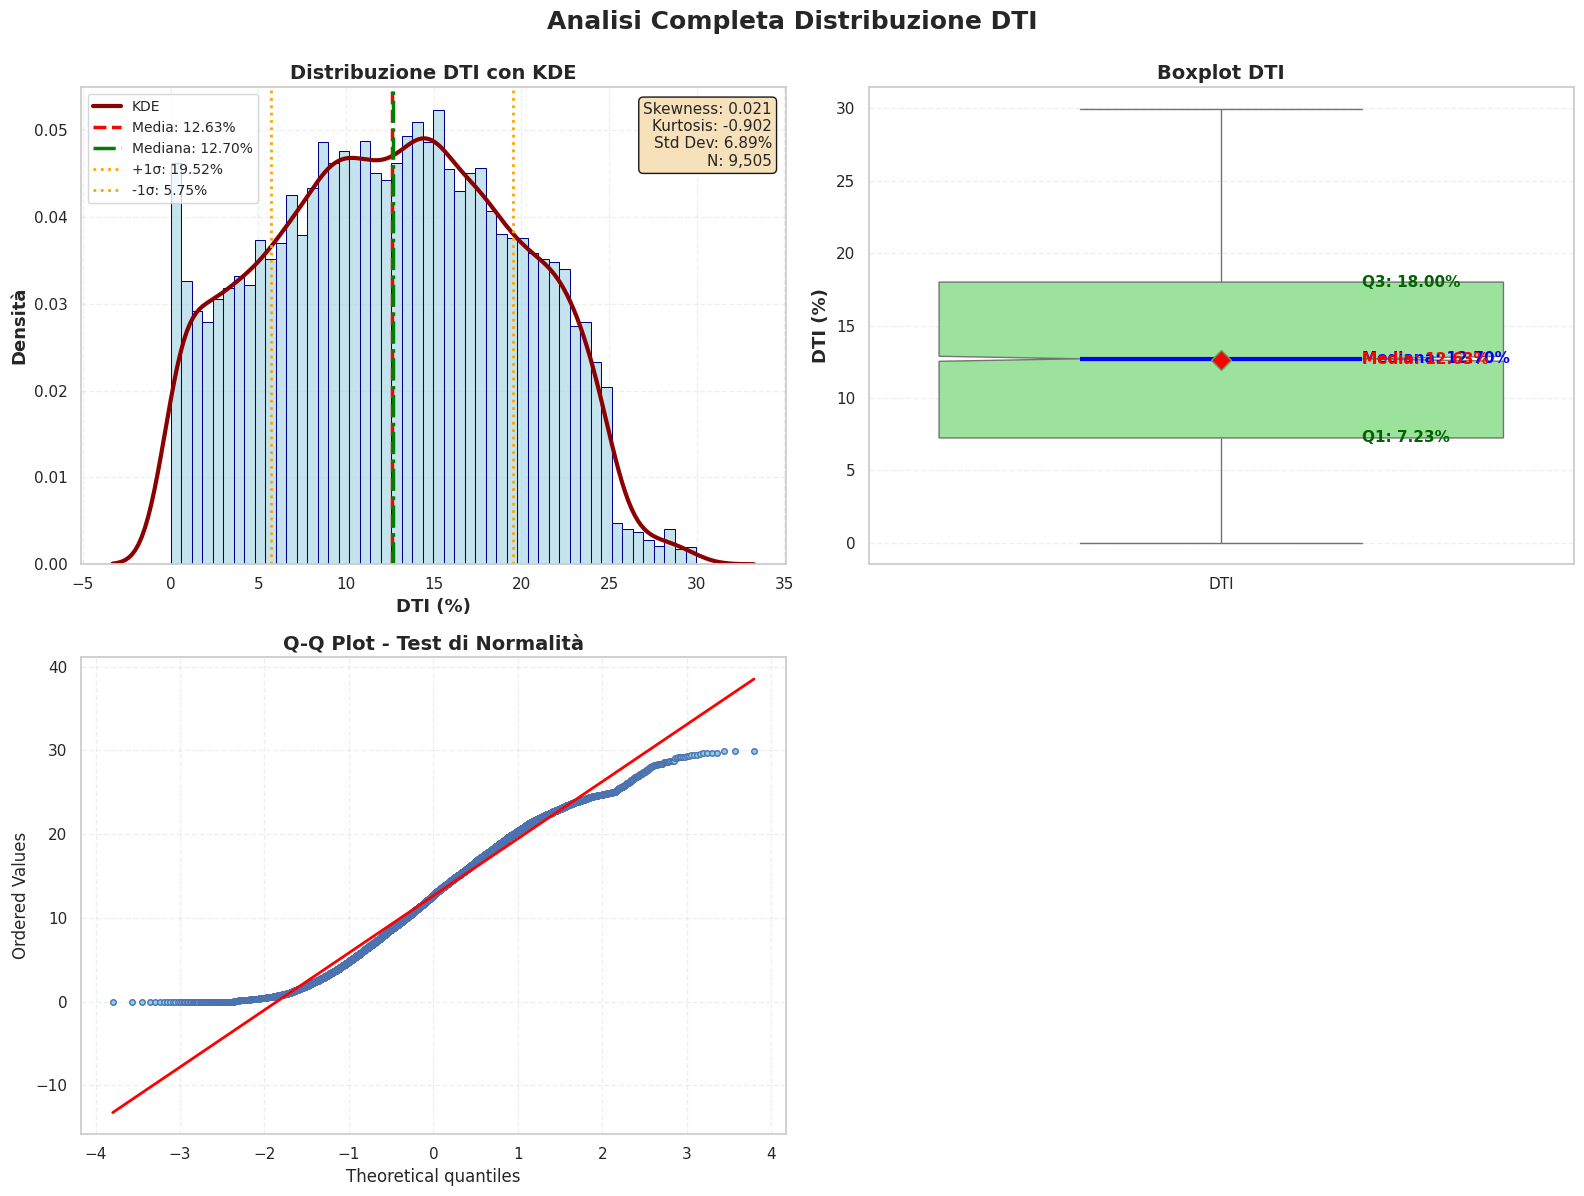

                    STATISTICHE DESCRITTIVE DTI
Media:              12.63%
Mediana:            12.70%
Dev. Standard:      6.89%
Skewness:           0.021
Kurtosis:           -0.902
DTI = 0:            86 (0.9048%)


In [ ]:

from scipy import stats as sp_stats

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisi Completa Distribuzione DTI', fontsize=18, fontweight='bold', y=0.995)

vals_dti = data['dti'].dropna()
mean_dti = vals_dti.mean()
median_dti = vals_dti.median()
std_dti = vals_dti.std()
skew_dti = vals_dti.skew()
kurt_dti = vals_dti.kurtosis()

sns.histplot(vals_dti, bins=50, color='lightblue', edgecolor='darkblue',
             alpha=0.7, stat='density', kde=False, ax=axes[0, 0])
sns.kdeplot(vals_dti, color='darkred', linewidth=3, ax=axes[0, 0], label='KDE')

axes[0, 0].axvline(mean_dti, color='red', linestyle='--', linewidth=2.5, label=f'Media: {mean_dti:.2f}%')
axes[0, 0].axvline(median_dti, color='green', linestyle='-.', linewidth=2.5, label=f'Mediana: {median_dti:.2f}%')
axes[0, 0].axvline(mean_dti + std_dti, color='orange', linestyle=':', linewidth=2, label=f'+1σ: {(mean_dti + std_dti):.2f}%')
axes[0, 0].axvline(mean_dti - std_dti, color='orange', linestyle=':', linewidth=2, label=f'-1σ: {(mean_dti - std_dti):.2f}%')

textstr = f'Skewness: {skew_dti:.3f}\nKurtosis: {kurt_dti:.3f}\nStd Dev: {std_dti:.2f}%\nN: {len(vals_dti):,}'
axes[0, 0].text(0.98, 0.97, textstr, transform=axes[0, 0].transAxes, fontsize=11,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9, edgecolor='black'))

axes[0, 0].set_xlabel('DTI (%)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Densità', fontsize=13, fontweight='bold')
axes[0, 0].set_title('Distribuzione DTI con KDE', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10, loc='upper left')
axes[0, 0].grid(True, alpha=0.3, linestyle='--')

bp = sns.boxplot(y=vals_dti, color='lightgreen', ax=axes[0, 1],
                 notch=True, showmeans=True, showcaps=True,
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=10),
                 medianprops=dict(color='blue', linewidth=3))

q1_dti = vals_dti.quantile(0.25)
q3_dti = vals_dti.quantile(0.75)

axes[0, 1].text(0.2, q1_dti, f'Q1: {q1_dti:.2f}%', fontsize=11, va='center', fontweight='bold', color='darkgreen')
axes[0, 1].text(0.2, median_dti, f'Mediana: {median_dti:.2f}%', fontsize=11, va='center', fontweight='bold', color='blue')
axes[0, 1].text(0.2, q3_dti, f'Q3: {q3_dti:.2f}%', fontsize=11, va='center', fontweight='bold', color='darkgreen')
axes[0, 1].text(0.2, mean_dti, f'Media: {mean_dti:.2f}%', fontsize=11, va='center', fontweight='bold', color='red')

axes[0, 1].set_ylabel('DTI (%)', fontsize=13, fontweight='bold')
axes[0, 1].set_title('Boxplot DTI', fontsize=14, fontweight='bold')
axes[0, 1].set_xticklabels(['DTI'])
axes[0, 1].grid(True, alpha=0.3, axis='y', linestyle='--')

sp_stats.probplot(vals_dti, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot - Test di Normalità', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, linestyle='--')
axes[1, 0].get_lines()[0].set_markerfacecolor('skyblue')
axes[1, 0].get_lines()[0].set_markersize(4)
axes[1, 0].get_lines()[1].set_color('red')
axes[1, 0].get_lines()[1].set_linewidth(2)

axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("="*70)
print(" "*20 + "STATISTICHE DESCRITTIVE DTI")
print("="*70)
print(f"Media:              {mean_dti:.2f}%")
print(f"Mediana:            {median_dti:.2f}%")
print(f"Dev. Standard:      {std_dti:.2f}%")
print(f"Skewness:           {skew_dti:.3f}")
print(f"Kurtosis:           {kurt_dti:.3f}")
print(f"DTI = 0:            {len(data[data['dti'] == 0])} ({(len(data[data['dti'] == 0]) / len(data)) * 100:.4f}%)")
print("="*70)

CONFRONTIAMO IL NUMERO DI PERSONE CHE HANNO DTI = 0, SE QUESTI HANNO UNA PERCENTUALE ALTA, ALLORA E' SOSPETTO

In [ ]:
print(f"Clienti con DTI = 0: {len(data[data['dti'] == 0])}")
print(f"Percentuale: {(len(data[data['dti'] == 0]) / len(data)) * 100:.2f}%")



Clienti con DTI = 0: 86
Percentuale: 0.90%


## Revolving balance is the actual debt you carry on a credit card or line of credit, while utilization (or revolving utilization) is the percentage of your total available revolving credit that balance represents (Balance / Credit Limit) and is a key factor in your credit score, with lower being better. Think of it as: Your balance is how much you owe; utilization is how much of your available credit you're using.

**ANALISI REVOLVING_UTIL**

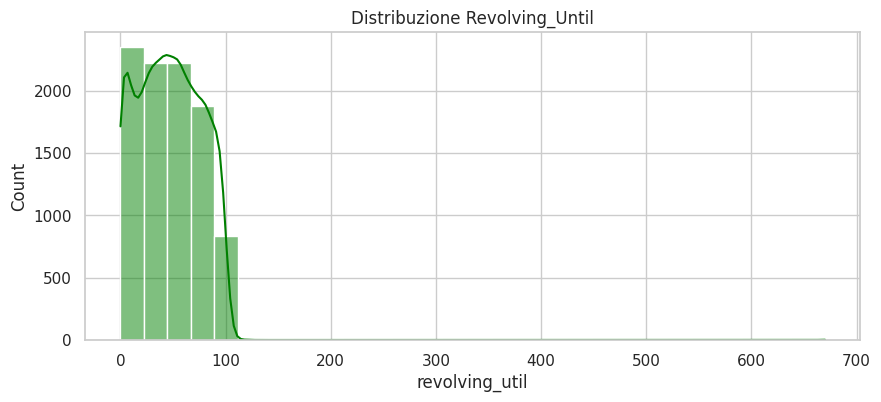

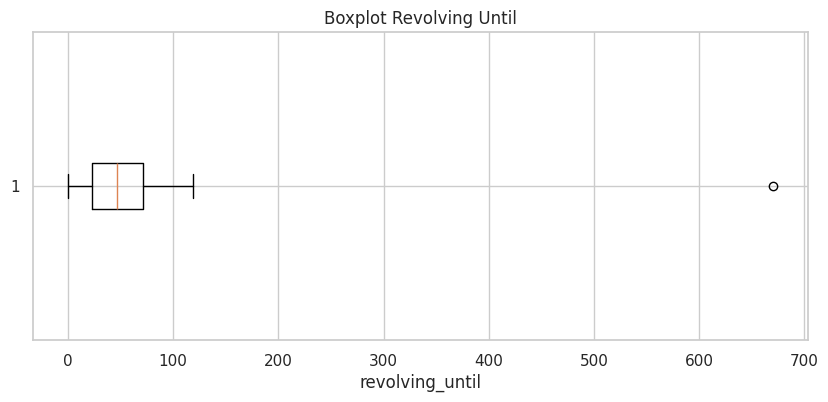

STATISTICHE DESCRITTIVE:

count    9505.000000
mean       46.937610
std        29.711429
min         0.000000
25%        22.700000
50%        46.400000
75%        71.000000
max       670.000000
Name: revolving_util, dtype: float64


In [ ]:
plt.figure(figsize=(10,4))
sns.histplot(data['revolving_util'], kde=True, bins=30, color='green')
plt.title('Distribuzione Revolving_Until')

plt.figure(figsize=(10,4))
plt.boxplot(data['revolving_util'], vert=False)
plt.title('Boxplot Revolving Until')
plt.xlabel('revolving_until')

plt.show()

print('STATISTICHE DESCRITTIVE:\n')
print(data['revolving_util'].describe())

ATTENZIONE: Questo è un valore anomalo molto significativo. Poiché l'utilizzo del credito rotativo è una percentuale che non dovrebbe superare il $100\%$ (a meno di un errore di calcolo o particolari situazioni di superamento del limite), il valore di $670.00$ è quasi certamente un outlier (valore anomalo) o un errore di immissione dati. Potrebbe indicare un errore nel modo in cui è stata registrata la percentuale (forse è stata moltiplicata per 1000, o rappresenta una situazione estrema di superamento del limite).

In [ ]:
Q1 = data['revolving_util'].quantile(0.25)
Q3 = data['revolving_util'].quantile(0.75)
IQR = Q3 - Q1

lowerB_r_u = Q1 - 1.5 * IQR
upperB_r_u = Q3 + 1.5 * IQR

print(f'Limite Inferiore: {lowerB_r_u: .2f}')
print(f'Limite Superiore: {upperB_r_u: .2f}')

lower_outliers = data[data['revolving_util'] < lowerB_r_u]

# Filtrare gli upper outliers
upper_outliers = data[data['revolving_util'] > upperB_r_u]

print("Numero di lower outliers:", len(lower_outliers))
print("Numero di upper outliers:", len(upper_outliers))


data= data[(data['revolving_util'] >= lowerB_r_u) & (data['revolving_util'] <= upperB_r_u)]
print(f'DIMENSIONE DATASET PULITO (SENZA OUTLIERS) : {data.shape[0]} righe')

Limite Inferiore: -49.75
Limite Superiore:  143.45
Numero di lower outliers: 0
Numero di upper outliers: 1
DIMENSIONE DATASET PULITO (SENZA OUTLIERS) : 9504 righe


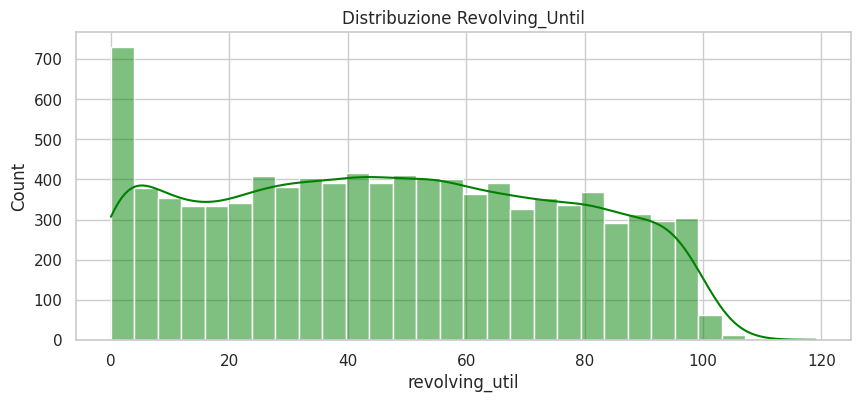

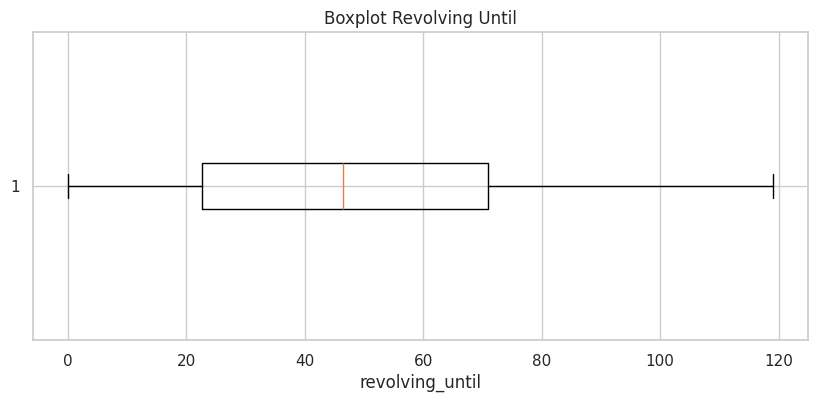

STATISTICHE DESCRITTIVE:

count    9504.000000
mean       46.872052
std        29.017351
min         0.000000
25%        22.700000
50%        46.400000
75%        71.000000
max       119.000000
Name: revolving_util, dtype: float64


In [ ]:
plt.figure(figsize=(10,4))
sns.histplot(data['revolving_util'], kde=True, bins=30, color='green')
plt.title('Distribuzione Revolving_Until')

plt.figure(figsize=(10,4))
plt.boxplot(data['revolving_util'], vert=False)
plt.title('Boxplot Revolving Until')
plt.xlabel('revolving_until')

plt.show()

print('STATISTICHE DESCRITTIVE:\n')
print(data['revolving_util'].describe())

Il nuovo valore massimo di $119.00$ (che probabilmente rappresenta l'osservazione con l'utilizzo più alto dopo la rimozione del $670.00$) è molto più ragionevole di $670.00$.Un utilizzo del $119\%$ è ancora molto alto e indica che l'individuo ha superato il proprio limite di credito (over-limit).Tuttavia, rispetto a $670\%$, il $119\%$ è un dato plausibile in un contesto finanziario reale (sebbene problematico per il debitore).ConclusioneL'operazione che hai eseguito per gestire l'outlier (probabilmente una rimozione o un capping del valore a $119.00$ o poco meno, dato che il conteggio è sceso di uno) è stata efficace.Ora hai una distribuzione della variabile revolving_util molto più pulita e statisticamente robusta, pronta per analisi e modellazioni più affidabili.

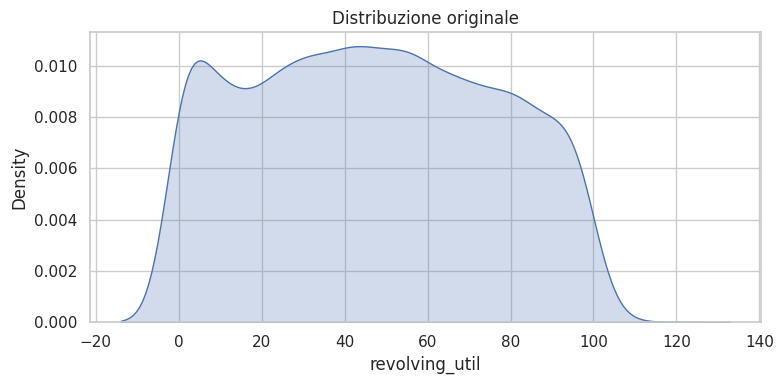


REVOLVING_UTIL
Asimmetria_Skewness: 0.06 | Kurtosis: -1.12
0.0


In [ ]:
sns.set(style="whitegrid")

skew = data['revolving_util'].skew()
kurt = data['revolving_util'].kurt()


fig, axes = plt.subplots(1, 1, figsize=(8, 4))
sns.kdeplot(data['revolving_util'], ax = axes, fill=True)
axes.set_title('Distribuzione originale')


plt.tight_layout()
plt.show()

for col in ['revolving_util']:
    print(f"\n{col.upper()}")
    print(f"Asimmetria_Skewness: {data[col].skew():.2f} | Kurtosis: {data[col].kurt():.2f}")

print(data['revolving_util'].min())

# ANALISI MULTIVARIATA

Esploriamo ora le relazioni tra variabili usando i metodi di analisi dell'associazione. Studieremo tre variabili chiave: DTI (debt-to-income ratio), Interest Rate (tasso di interesse) e FICO Score (punteggio creditizio).

Obiettivo: capire come queste variabili si correlano tra loro e con altre caratteristiche dei prestiti. Useremo Pearson correlation, covariance, scatter plots, correlation matrices e distribuzioni condizionate per confrontare gruppi.

---
## 1. ANALISI DTI (Debt-to-Income Ratio)

### 1.1 Associazione DTI con altre variabili

studiamo la correlazione tra dti e le principali variabili del dataset usando pearson e covarianza

# TO DO Test statistico
Cerchiamo la correlazione tra DTI e annual income e installment, H0

In [ ]:
dti_vars = ['log_annual_income', 'installment']

print("╔" + "="*78 + "╗")
print("║" + " ASSOCIAZIONE DTI CON ALTRE VARIABILI".center(78) + "║")
print("╠" + "="*78 + "╣")
print(f"║ {'Variabile':<30} {'Pearson ρ':>20} {'Covariance':>20} ║")
print("╠" + "="*78 + "╣")

dti_correlations = {}
dti_covariances = {}
for var in dti_vars:
    dti_correlations[var] = data['dti'].corr(data[var])
    dti_covariances[var] = data['dti'].cov(data[var])
    print(f"║ {var:<30} {dti_correlations[var]:>20.4f} {dti_covariances[var]:>20.2f} ║")

print("╚" + "="*78 + "╝")

sorted_corr = sorted(dti_correlations.items(), key=lambda x: abs(x[1]), reverse=True)
print(f"\nCorrelazioni con DTI:")
for i, (var, corr) in enumerate(sorted_corr[:3], 1):
    direction = "positiva" if corr > 0 else "negativa"
    print(f"   {i}. {var}: ρ = {corr:.4f} (correlazione {direction})")

╔==============================================================================╗
║                     ASSOCIAZIONE DTI CON ALTRE VARIABILI                     ║
╠==============================================================================╣
║ Variabile                                 Pearson ρ           Covariance ║
╠==============================================================================╣
║ log_annual_income                           -0.0535                -0.22 ║
║ installment                                  0.0474                67.67 ║
╚==============================================================================╝

Correlazioni con DTI:
   1. log_annual_income: ρ = -0.0535 (correlazione negativa)
   2. installment: ρ = 0.0474 (correlazione positiva)


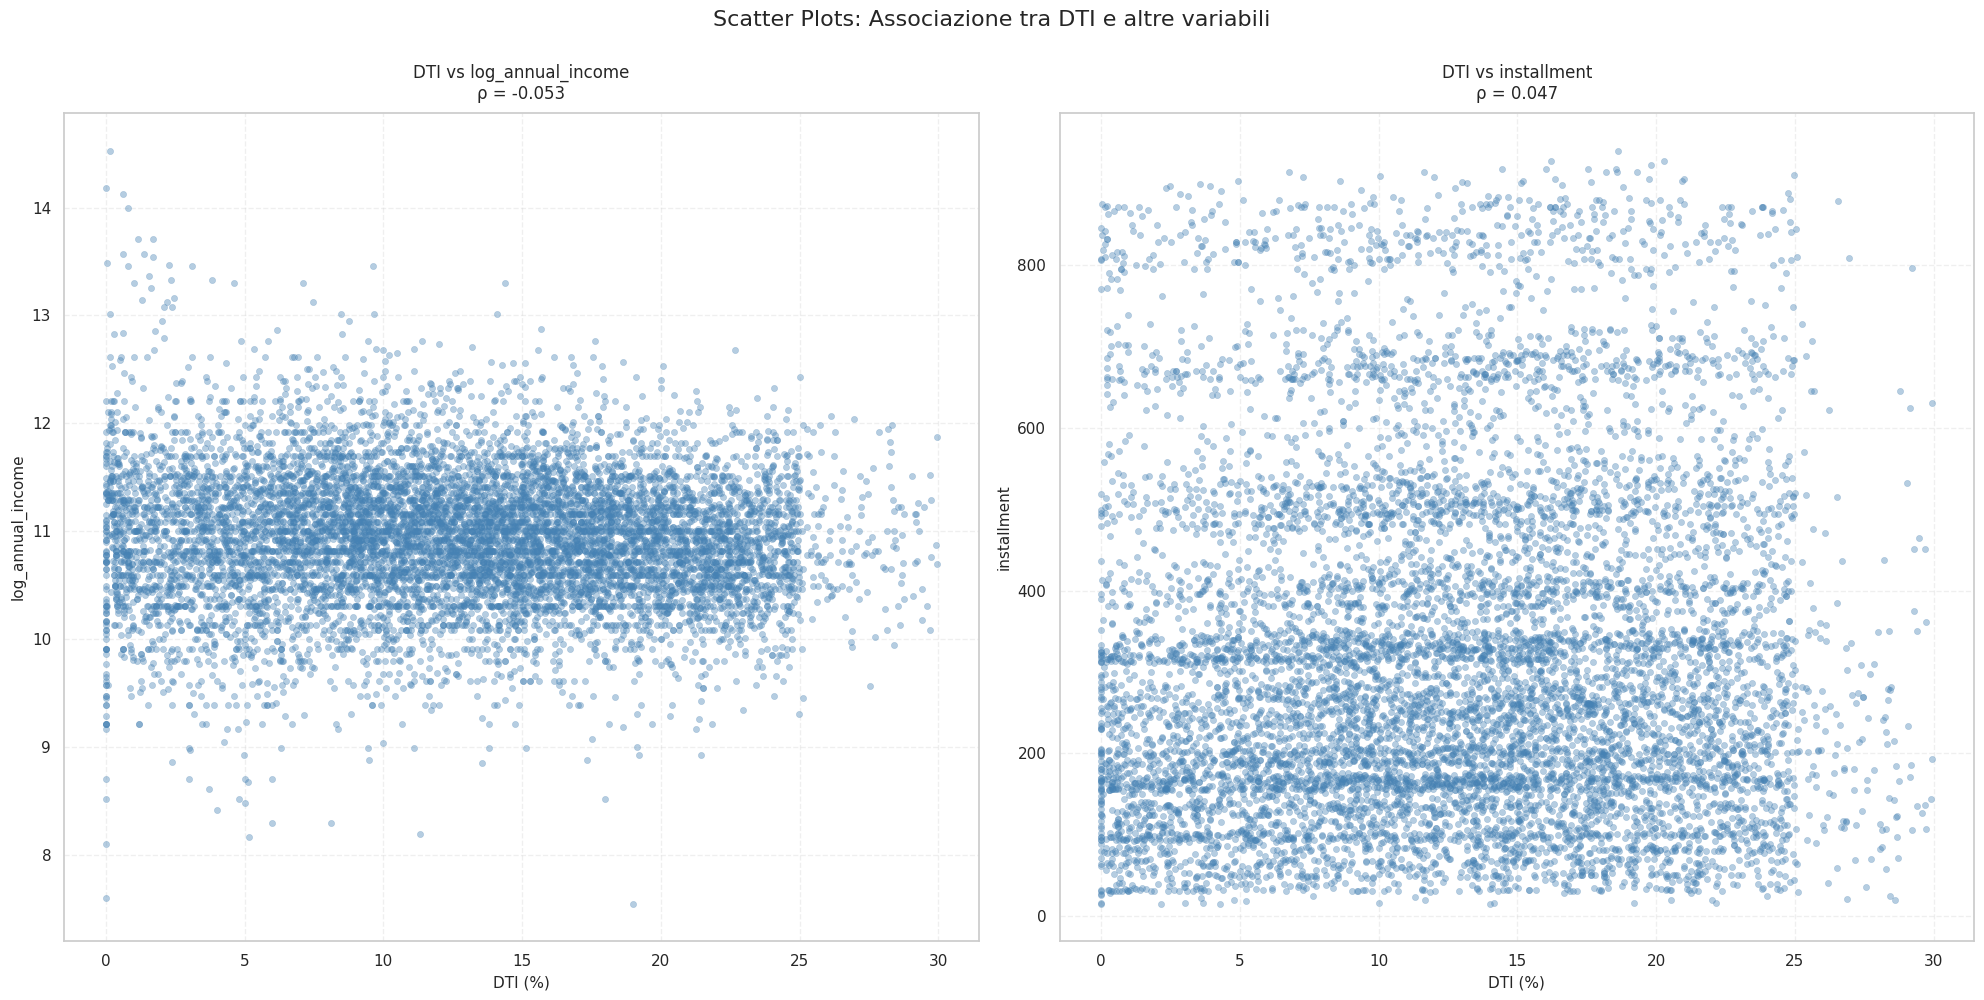

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes = axes.flatten()

for idx, var in enumerate(dti_vars):
    sns.scatterplot(data=data, x='dti', y=var, alpha=0.4, s=20,
                   color='steelblue', edgecolor=None, ax=axes[idx])

    axes[idx].set_xlabel('DTI (%)', fontsize=11)
    axes[idx].set_ylabel(var, fontsize=11)
    axes[idx].set_title(f'DTI vs {var}\nρ = {dti_correlations[var]:.3f}',
                       fontsize=12, pad=10)
    axes[idx].grid(True, alpha=0.3, linestyle='--')



plt.suptitle('Scatter Plots: Associazione tra DTI e altre variabili',
             fontsize=16, y=0.998)
plt.tight_layout()
plt.show()

# Non ha una forte correlazione come per definizione

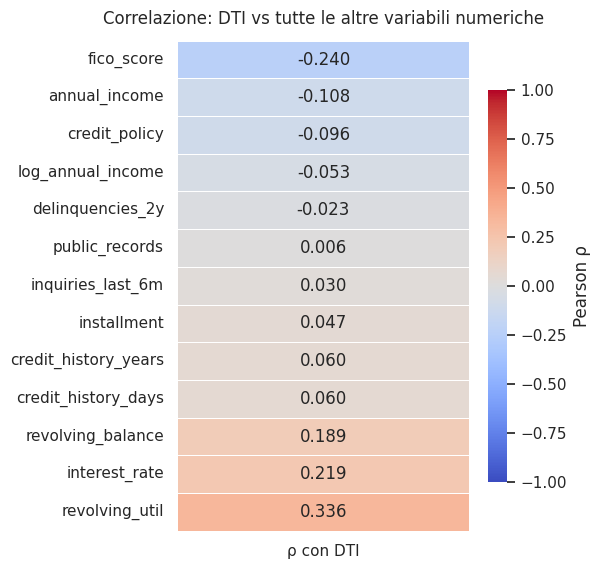

,ρ con DTI
revolving_util,0.336081
interest_rate,0.219001
revolving_balance,0.189482
credit_history_days,0.060429
credit_history_years,0.060429
installment,0.047448
inquiries_last_6m,0.030212
public_records,0.006204
delinquencies_2y,-0.022935
log_annual_income,-0.053488


In [ ]:
# Matrice (1-colonna) delle correlazioni: solo DTI vs tutte le altre variabili numeriche
df_num = data.select_dtypes(include=[np.number]).copy()

# Escludi identificativi e verifica DTI
for col in ['customer_id']:
    if col in df_num.columns:
        df_num = df_num.drop(columns=col)

if 'dti' not in df_num.columns:
    raise ValueError("La colonna 'dti' non è presente o non è numerica.")

# Serie delle correlazioni con DTI (Pearson), ordinate
corr_dti = df_num.corr(method='pearson')['dti'].drop('dti').sort_values()

# DataFrame a 1 colonna per heatmap
corr_df = corr_dti.to_frame(name='ρ con DTI')

# Heatmap verticale
n = len(corr_df)
fig_h = min(max(0.45 * n, 5), 24)
fig, ax = plt.subplots(figsize=(6, fig_h))
sns.heatmap(
    corr_df,
    annot=True, fmt='.3f', cmap='coolwarm', center=0,
    vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"shrink": 0.8, "label": "Pearson ρ"},
    ax=ax
)
ax.set_title("Correlazione: DTI vs tutte le altre variabili numeriche", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

display(corr_df.sort_values('ρ con DTI', ascending=False))

### 1.2 Distribuzioni Condizionate del DTI

confrontiamo la distribuzione del dti per diversi gruppi condizionati su altre variabili categoriche

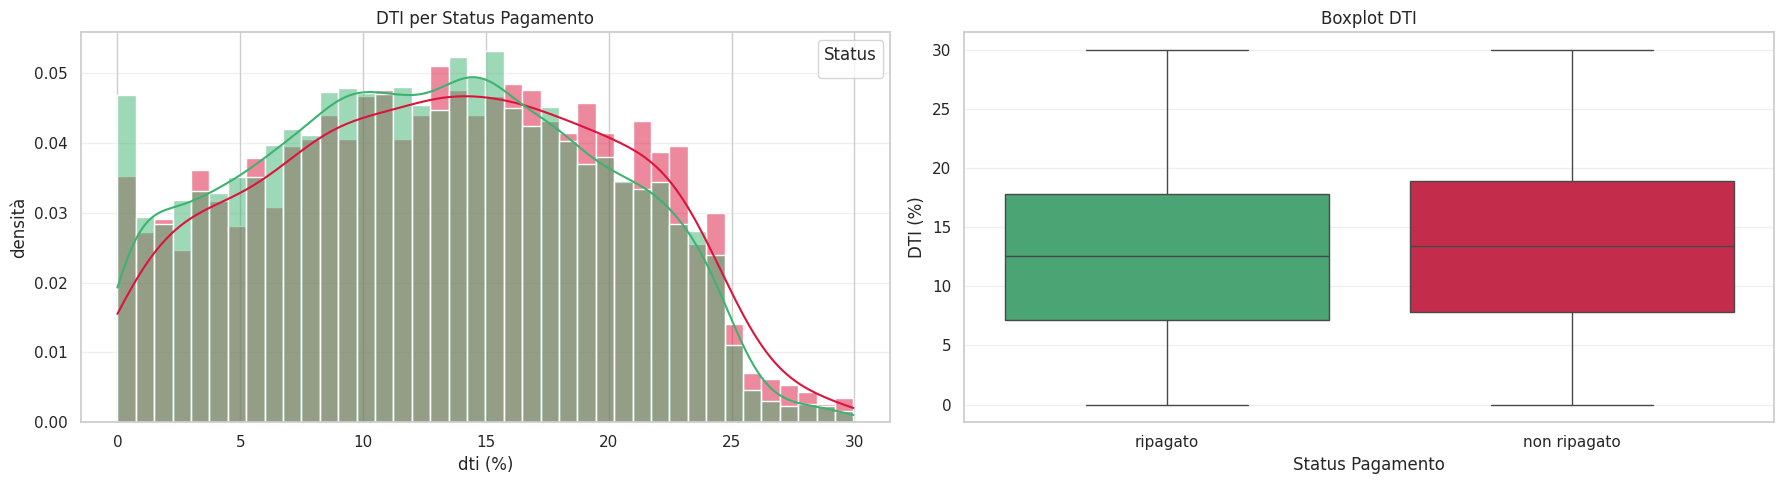


Statistiche DTI per Status Pagamento:

ripagato:
  media: 12.52%
  mediana: 12.58%
  std: 6.86%
  q1-q3: [7.13%, 17.82%]

non ripagato:
  media: 13.23%
  mediana: 13.38%
  std: 7.02%
  q1-q3: [7.83%, 18.90%]


In [ ]:
data['not_fully_paid'] = data['not_fully_paid'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data=data, x='dti', hue='not_fully_paid', bins=40, kde=True,
             palette={'0': 'mediumseagreen', '1': 'crimson'}, alpha=0.5,
             ax=axes[0], stat='density', common_norm=False)
axes[0].set_xlabel('dti (%)')
axes[0].set_ylabel('densità')
axes[0].set_title('DTI per Status Pagamento')

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, ['ripagato', 'non ripagato'], title='Status')
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(data=data, x='not_fully_paid', y='dti',
            palette={'0': 'mediumseagreen', '1': 'crimson'}, ax=axes[1],
            hue='not_fully_paid', legend=False)
axes[1].set_xlabel('Status Pagamento')
axes[1].set_ylabel('DTI (%)')
axes[1].set_title('Boxplot DTI')
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['ripagato', 'non ripagato'])
axes[1].grid(True, alpha=0.3, axis='y')



plt.tight_layout()
plt.show()

print("\nStatistiche DTI per Status Pagamento:")
print("="*50)

for status in ['0', '1']:
    dti_group = data[data['not_fully_paid'] == status]['dti']
    status_name = "ripagato" if status == '0' else "non ripagato"
    print(f"\n{status_name}:")
    print(f"  media: {dti_group.mean():.2f}%")
    print(f"  mediana: {dti_group.median():.2f}%")
    print(f"  std: {dti_group.std():.2f}%")
    print(f"  q1-q3: [{dti_group.quantile(0.25):.2f}%, {dti_group.quantile(0.75):.2f}%]")

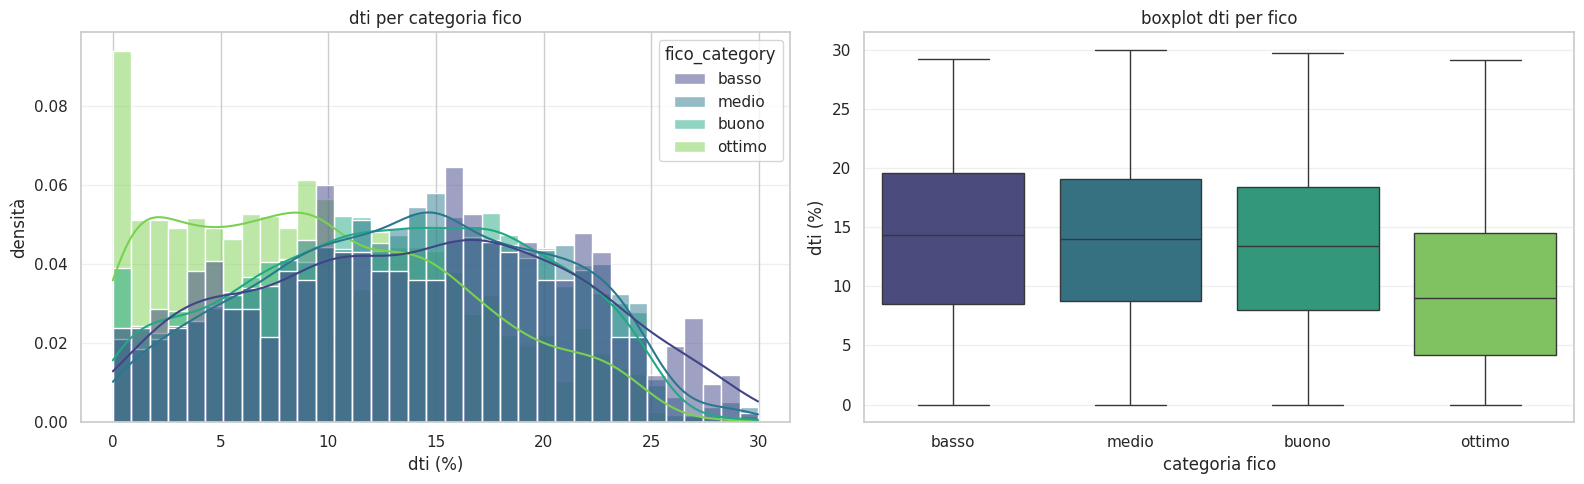

Statistiche dti per categoria fico:

fico basso:
  media: 14.00%
  mediana: 14.34%
  count: 487 prestiti (5.1%)

fico medio:
  media: 13.79%
  mediana: 14.00%
  count: 3701 prestiti (38.9%)

fico buono:
  media: 13.11%
  mediana: 13.38%
  count: 3105 prestiti (32.7%)

fico ottimo:
  media: 9.72%
  mediana: 9.03%
  count: 2211 prestiti (23.3%)


In [ ]:
data['fico_category'] = pd.cut(
    data['fico_score'],
    bins=[600, 660, 700, 740, 850],
    labels=['basso', 'medio', 'buono', 'ottimo']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=data,
    x='dti',
    hue='fico_category',
    bins=35,
    kde=True,
    palette='viridis',
    alpha=0.5,
    ax=axes[0],
    stat='density',
    common_norm=False
)
axes[0].set_xlabel('dti (%)')
axes[0].set_ylabel('densità')
axes[0].set_title('dti per categoria fico')
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(
    data=data,
    x='fico_category',
    y='dti',
    hue='fico_category',
    legend=False,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_xlabel('categoria fico')
axes[1].set_ylabel('dti (%)')
axes[1].set_title('boxplot dti per fico')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Statistiche dti per categoria fico:")
print("="*50)
for category in ['basso', 'medio', 'buono', 'ottimo']:
    dti_cat = data[data['fico_category'] == category]['dti'].dropna()
    print(f"\nfico {category}:")
    print(f"  media: {dti_cat.mean():.2f}%")
    print(f"  mediana: {dti_cat.median():.2f}%")
    print(f"  count: {len(dti_cat)} prestiti ({len(dti_cat)/len(data)*100:.1f}%)")


---
## 2. ANALISI INTEREST RATE

### 2.1 Associazione Interest Rate con altre variabili

analizziamo quali fattori sono correlati con il tasso di interesse applicato ai prestiti

In [ ]:
interest_vars = ['fico_score', 'dti', 'log_annual_income', 'revolving_util',
                'credit_history_days', 'revolving_balance', 'installment', 'not_fully_paid']

print("associazione interest rate con altre variabili")
print("="*70)
print(f"{'variabile':<30} {'pearson ρ':>18} {'covariance':>18}")
print("-"*70)

interest_correlations = {}
interest_covariances = {}
for var in interest_vars:
    interest_correlations[var] = data_clean['interest_rate'].corr(data[var])
    interest_covariances[var] = data_clean['interest_rate'].cov(data[var])
    print(f"{var:<30} {interest_correlations[var]:>18.4f} {interest_covariances[var]:>18.2f}")

print("="*70)

sorted_corr_int = sorted(interest_correlations.items(), key=lambda x: abs(x[1]), reverse=True)
print(f"\ntop 3 correlazioni con interest rate:")
for i, (var, corr) in enumerate(sorted_corr_int[:3], 1):
    direction = "positiva" if corr > 0 else "negativa"
    print(f"  {i}. {var}: ρ = {corr:.4f} (correlazione {direction})")

associazione interest rate con altre variabili
variabile                               pearson ρ         covariance
----------------------------------------------------------------------
fico_score                                -0.7218             -71.75
dti                                        0.2268               4.09
log_annual_income                          0.0510               0.08
revolving_util                             0.4718              35.83
credit_history_days                       -0.1247            -815.35
revolving_balance                          0.0844            7102.19
installment                                0.2706             146.17
not_fully_paid                             0.1567               0.15

top 3 correlazioni con interest rate:
  1. fico_score: ρ = -0.7218 (correlazione negativa)
  2. revolving_util: ρ = 0.4718 (correlazione positiva)
  3. installment: ρ = 0.2706 (correlazione positiva)


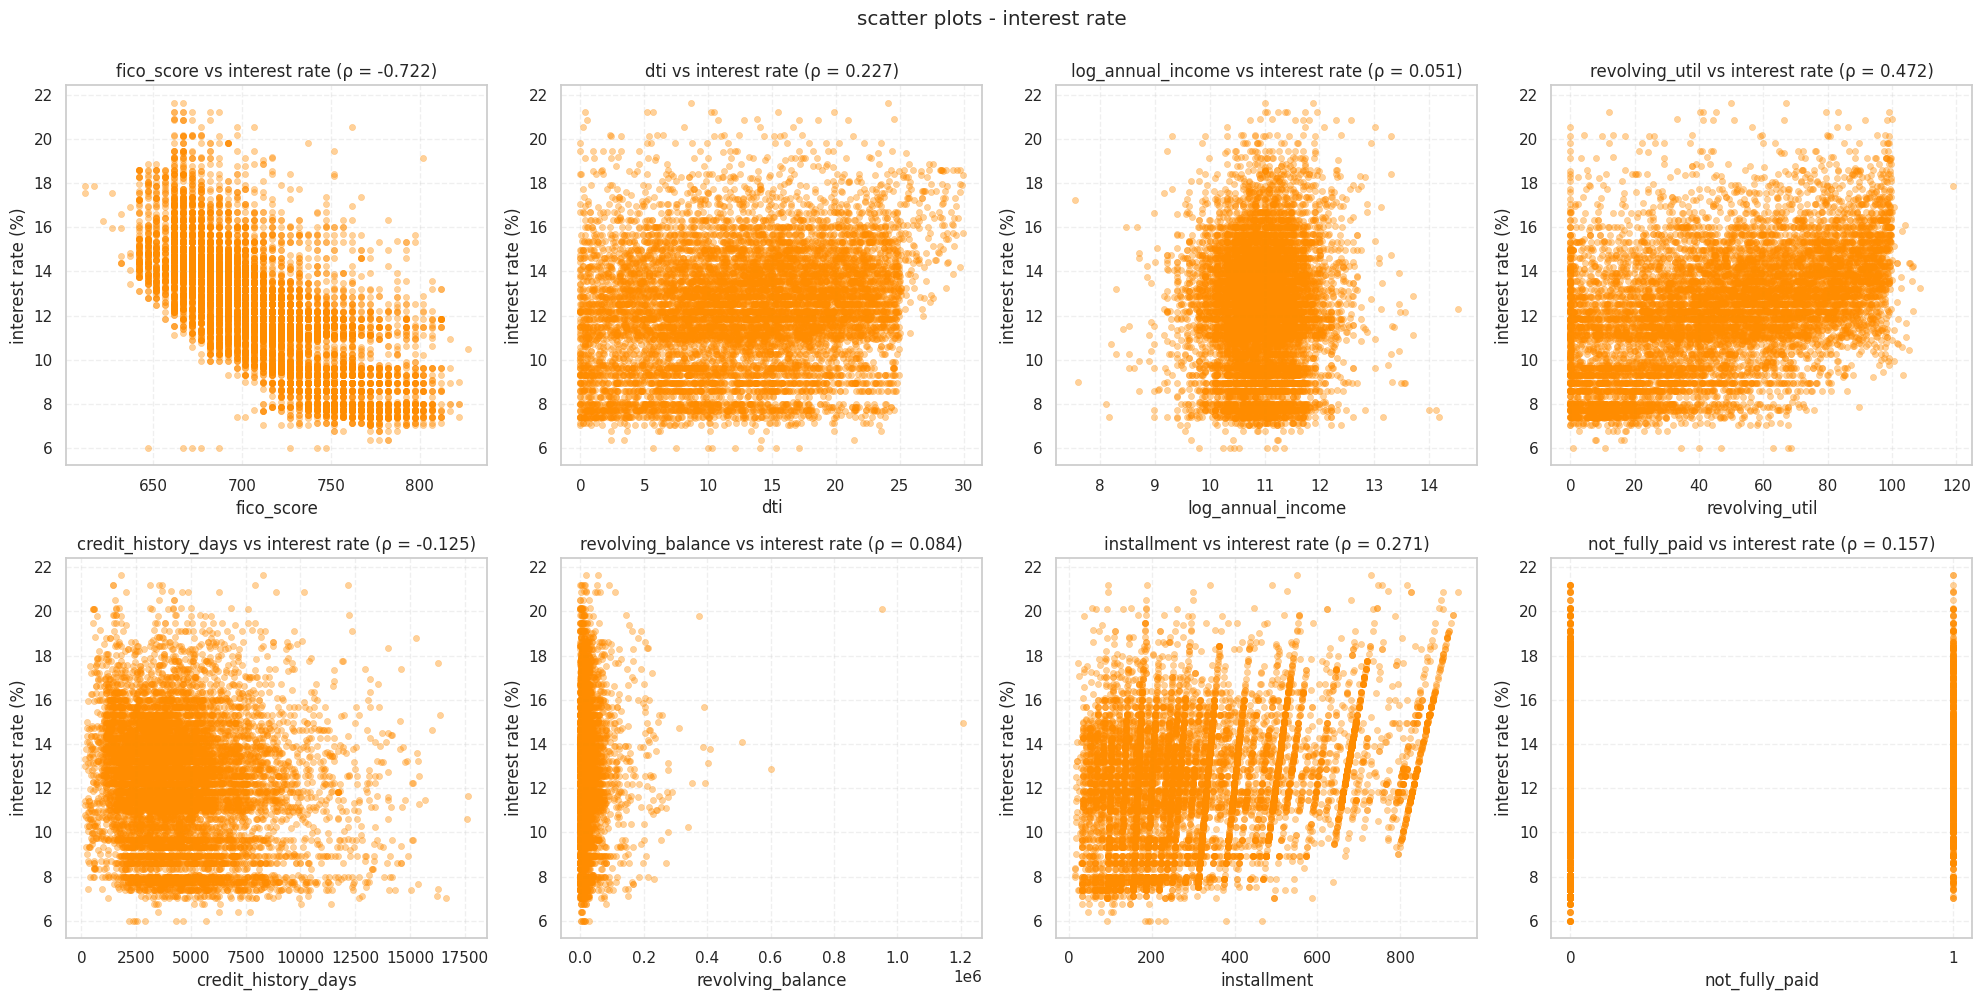

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, var in enumerate(interest_vars):
    sns.scatterplot(data=data, x=var, y='interest_rate', alpha=0.4, s=20,
                   color='darkorange', edgecolor=None, ax=axes[idx])

    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('interest rate (%)')
    axes[idx].set_title(f'{var} vs interest rate (ρ = {interest_correlations[var]:.3f})')
    axes[idx].grid(True, alpha=0.3, linestyle='--')

plt.suptitle('scatter plots - interest rate', y=0.998)
plt.tight_layout()
plt.show()

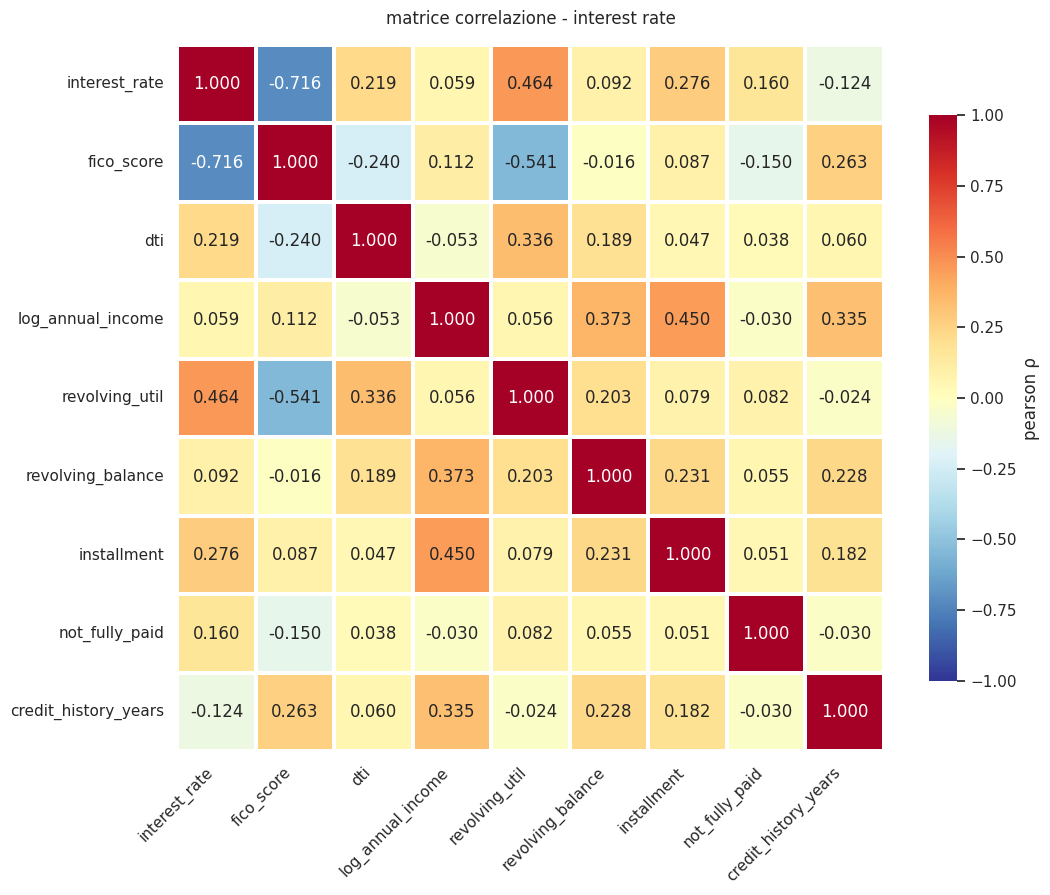

In [ ]:
correlation_vars_int = ['interest_rate', 'fico_score', 'dti', 'log_annual_income',
                        'revolving_util', 'revolving_balance', 'installment', 'not_fully_paid', 'credit_history_years']

corr_matrix_int = data[correlation_vars_int].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix_int, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            square=True, linewidths=1.5, cbar_kws={"shrink": 0.8, "label": "pearson ρ"},
            vmin=-1, vmax=1, ax=ax)
plt.title('matrice correlazione - interest rate', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.2 Distribuzioni Condizionate dell'Interest Rate

# TO DO, perchè ci sono outlier ? nel senso perche persone con FICO score ottimo, hanno interest alto

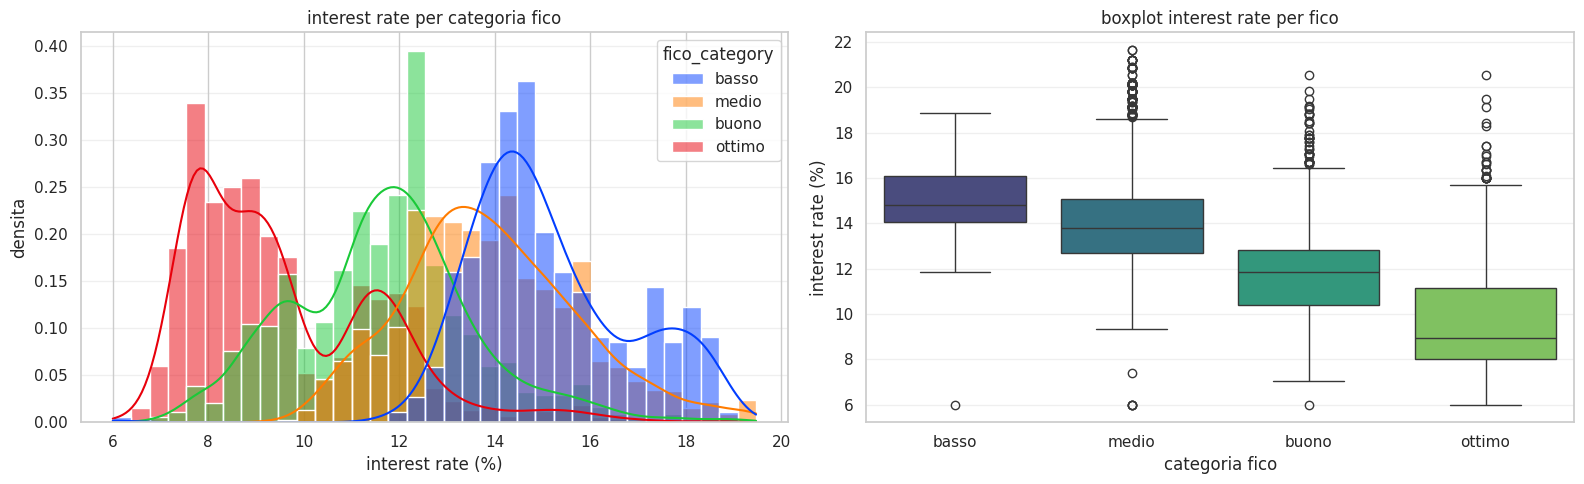

statistiche interest rate per categoria fico:

fico basso:
  media: 15.14%
  mediana: 14.82%

fico medio:
  media: 13.90%
  mediana: 13.79%

fico buono:
  media: 11.67%
  mediana: 11.83%

fico ottimo:
  media: 9.60%
  mediana: 8.94%


In [ ]:
data_merged = data.copy()
data_merged['interest_rate'] = data_clean['interest_rate']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=data_merged,
    x='interest_rate',
    hue='fico_category',
    bins=35,
    kde=True,
    palette='bright',
    alpha=0.5,
    ax=axes[0],
    stat='density',
    common_norm=False
)
axes[0].set_xlabel('interest rate (%)')
axes[0].set_ylabel('densita')
axes[0].set_title('interest rate per categoria fico')
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(
    data=data,
    x='fico_category',
    y='interest_rate',
    hue='fico_category',
    legend=False,
    palette='viridis',
    ax=axes[1]
)

axes[1].set_xlabel('categoria fico')
axes[1].set_ylabel('interest rate (%)')
axes[1].set_title('boxplot interest rate per fico')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("statistiche interest rate per categoria fico:")
print("="*50)
for category in ['basso', 'medio', 'buono', 'ottimo']:
    int_cat = data_merged[data_merged['fico_category'] == category]['interest_rate']
    print(f"\nfico {category}:")
    print(f"  media: {int_cat.mean():.2f}%")
    print(f"  mediana: {int_cat.median():.2f}%")



827
R^2 value: 0.5128078897369579
                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                 1.000e+04
Date:                Mon, 22 Dec 2025   Prob (F-statistic):               0.00
Time:                        10:24:56   Log-Likelihood:                -19439.
No. Observations:                9504   AIC:                         3.888e+04
Df Residuals:                    9502   BIC:                         3.890e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         48.2

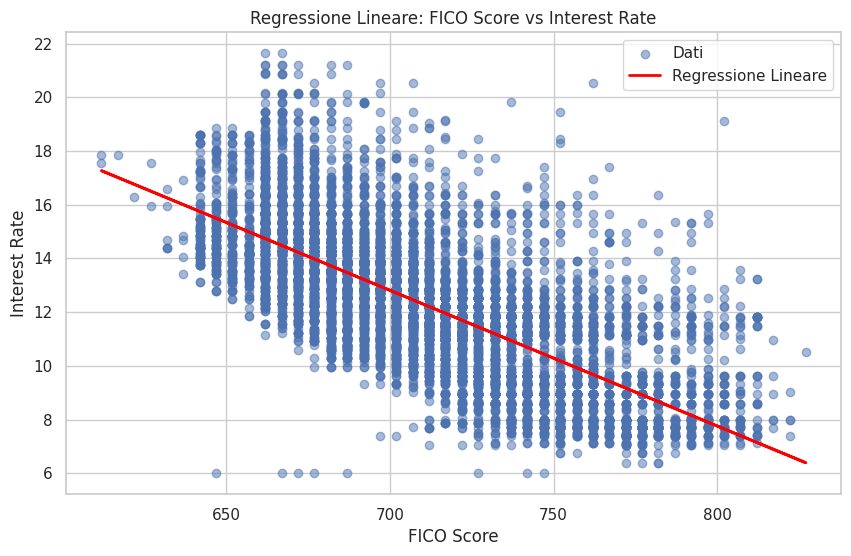

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Preparazione dei dati
X = data['fico_score']
y = data['interest_rate']

# Aggiunta della costante per l'intercetta
X_const = sm.add_constant(X)

# Creazione e fitting del modello
model = sm.OLS(y, X_const).fit()
print(data['fico_score'].max())
# Stampa del valore R^2
print(f"R^2 value: {model.rsquared}")

# Stampa del sommario della regressione
print(model.summary())


# Plot della regressione
plt.figure(figsize=(10, 6))
plt.scatter(data['fico_score'], y, alpha=0.5, label='Dati')
plt.plot(data['fico_score'], model.predict(X_const), color='red', linewidth=2, label='Regressione Lineare')
plt.xlabel('FICO Score')
plt.ylabel('Interest Rate')
plt.title('Regressione Lineare: FICO Score vs Interest Rate')
plt.legend()
plt.show()

In [ ]:

from scipy import stats


print("="*80)
print("ANALISI DI SIGNIFICATIVITÀ STATISTICA")
print("="*80)

# Seleziona colonne numeriche escludendo interest_rate
numeric_cols_clean = data.select_dtypes(include=[np.number]).columns.tolist()
if 'interest_rate' in numeric_cols_clean:
    numeric_cols_clean.remove('interest_rate')
if 'customer_id' in numeric_cols_clean:
    numeric_cols_clean.remove('customer_id')

print(f"\nVariabili analizzate: {numeric_cols_clean}\n")

# Calcola correlazioni e p-values
results = []

for col in numeric_cols_clean:
    # Filtra righe dove entrambe le variabili sono presenti
    valid_data = data[[col, 'interest_rate']].dropna()

    if len(valid_data) > 2:  # Almeno 3 punti
        corr, pvalue = stats.pearsonr(valid_data[col], valid_data['interest_rate'])
        results.append({
            'Variabile': col,
            'Correlazione': corr,
            'P-Value': pvalue,
            'Significativo': 'Sì' if pvalue < 0.05 else 'No'
        })

# Crea DataFrame e ordina per p-value
df_results = pd.DataFrame(results).sort_values('P-Value')

print("RISULTATI:")
print("="*80)
print(df_results.to_string(index=False))

# Variabili significative
sig_vars = df_results[df_results['P-Value'] < 0.05]['Variabile'].tolist()
print(f"\n\nVariabili Significative (p < 0.05):")
for var in sig_vars:
    print(f"  • {var}")


ANALISI DI SIGNIFICATIVITÀ STATISTICA

Variabili analizzate: ['credit_policy', 'installment', 'log_annual_income', 'dti', 'fico_score', 'credit_history_days', 'revolving_balance', 'revolving_util', 'inquiries_last_6m', 'delinquencies_2y', 'public_records', 'credit_history_years', 'annual_income']

RISULTATI:
           Variabile  Correlazione       P-Value Significativo
      revolving_util      0.463558  0.000000e+00            Sì
          fico_score     -0.716106  0.000000e+00            Sì
       credit_policy     -0.305546 1.600923e-204            Sì
         installment      0.275938 1.153507e-165            Sì
                 dti      0.219001 1.442676e-103            Sì
   inquiries_last_6m      0.207397  7.555757e-93            Sì
    delinquencies_2y      0.155697  1.214578e-52            Sì
 credit_history_days     -0.124241  5.224821e-34            Sì
credit_history_years     -0.124241  5.224821e-34            Sì
      public_records      0.099796  1.807863e-22            

In [ ]:

X_multi = sm.add_constant(df_clean[['fico_score', 'revolving_util', 'dti', 'installment']])
y_multi = df_clean['interest_rate']

model_multi = sm.OLS(y_multi, X_multi).fit()

print("\nRISULTATI MODELLO MULTIVARIATO:")
print(f"R² = {model_multi.rsquared:.4f}")
print(f"Adjusted R² = {model_multi.rsquared_adj:.4f}")
print(f"\nCoefficienti e p-values:")
print(model_multi.summary().tables[1])



RISULTATI MODELLO MULTIVARIATO:
R² = 0.6298
Adjusted R² = 0.6297

Coefficienti e p-values:
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             46.6573      0.397    117.612      0.000      45.880      47.435
fico_score        -0.0507      0.001    -95.248      0.000      -0.052      -0.050
revolving_util     0.0040      0.001      5.630      0.000       0.003       0.005
dti                0.0064      0.003      2.455      0.014       0.001       0.011
installment        0.0043   8.21e-05     52.672      0.000       0.004       0.004


## Conclusioni

**I tassi d'interesse non dipendono solo dai dati creditizi.** Le banche considerano anche:
- Condizioni di mercato
- Tipo e durata del prestito  
- Politiche interne
- Fattori che non abbiamo nei dati

I restanti **37% di varianza** sono dovuti a fattori non misurati, non a un modello sbagliato.

### I numeri che contano

- **R²**: 0.63 (63% della variazione spiegata)
- **Adj R²**: 0.63 (praticamente uguale, il modello è robusto)
- **Miglioramento**: +24% rispetto al modello con solo FICO score
- **Variabili importanti**: FICO score, revolving utilization, DTI, installment (tutte p < 0.001)

**Bottom line:** Con 4 variabili spieghiamo 63% dei tassi di interesse. Per fare meglio servirebbe dati su fattori che la banca non condivide pubblicamente.


---
## 3. ANALISI FICO SCORE

### 3.1 Associazione FICO Score con altre variabili

In [ ]:
fico_vars = ['dti', 'interest_rate', 'log_annual_income', 'revolving_util',
            'credit_history_days', 'revolving_balance', 'not_fully_paid']

print("associazione fico score con altre variabili")
print("="*70)
print(f"{'variabile':<30} {'pearson ρ':>18} {'covariance':>18}")
print("-"*70)

fico_correlations = {}
fico_covariances = {}
for var in fico_vars:
    fico_correlations[var] = data['fico_score'].corr(data[var])
    fico_covariances[var] = data['fico_score'].cov(data[var])
    print(f"{var:<30} {fico_correlations[var]:>18.4f} {fico_covariances[var]:>18.2f}")

print("="*70)

sorted_corr_fico = sorted(fico_correlations.items(), key=lambda x: abs(x[1]), reverse=True)
print(f"\ntop 3 correlazioni con fico score:")
for i, (var, corr) in enumerate(sorted_corr_fico[:3], 1):
    direction = "positiva" if corr > 0 else "negativa"
    print(f"  {i}. {var}: ρ = {corr:.4f} (correlazione {direction})")

associazione fico score con altre variabili
variabile                               pearson ρ         covariance
----------------------------------------------------------------------
dti                                       -0.2399             -62.69
interest_rate                             -0.7161             -72.83
log_annual_income                          0.1118               2.59
revolving_util                            -0.5408            -595.35
credit_history_days                        0.2629           24920.40
revolving_balance                         -0.0156          -19970.24
not_fully_paid                            -0.1496              -2.08

top 3 correlazioni con fico score:
  1. interest_rate: ρ = -0.7161 (correlazione negativa)
  2. revolving_util: ρ = -0.5408 (correlazione negativa)
  3. credit_history_days: ρ = 0.2629 (correlazione positiva)


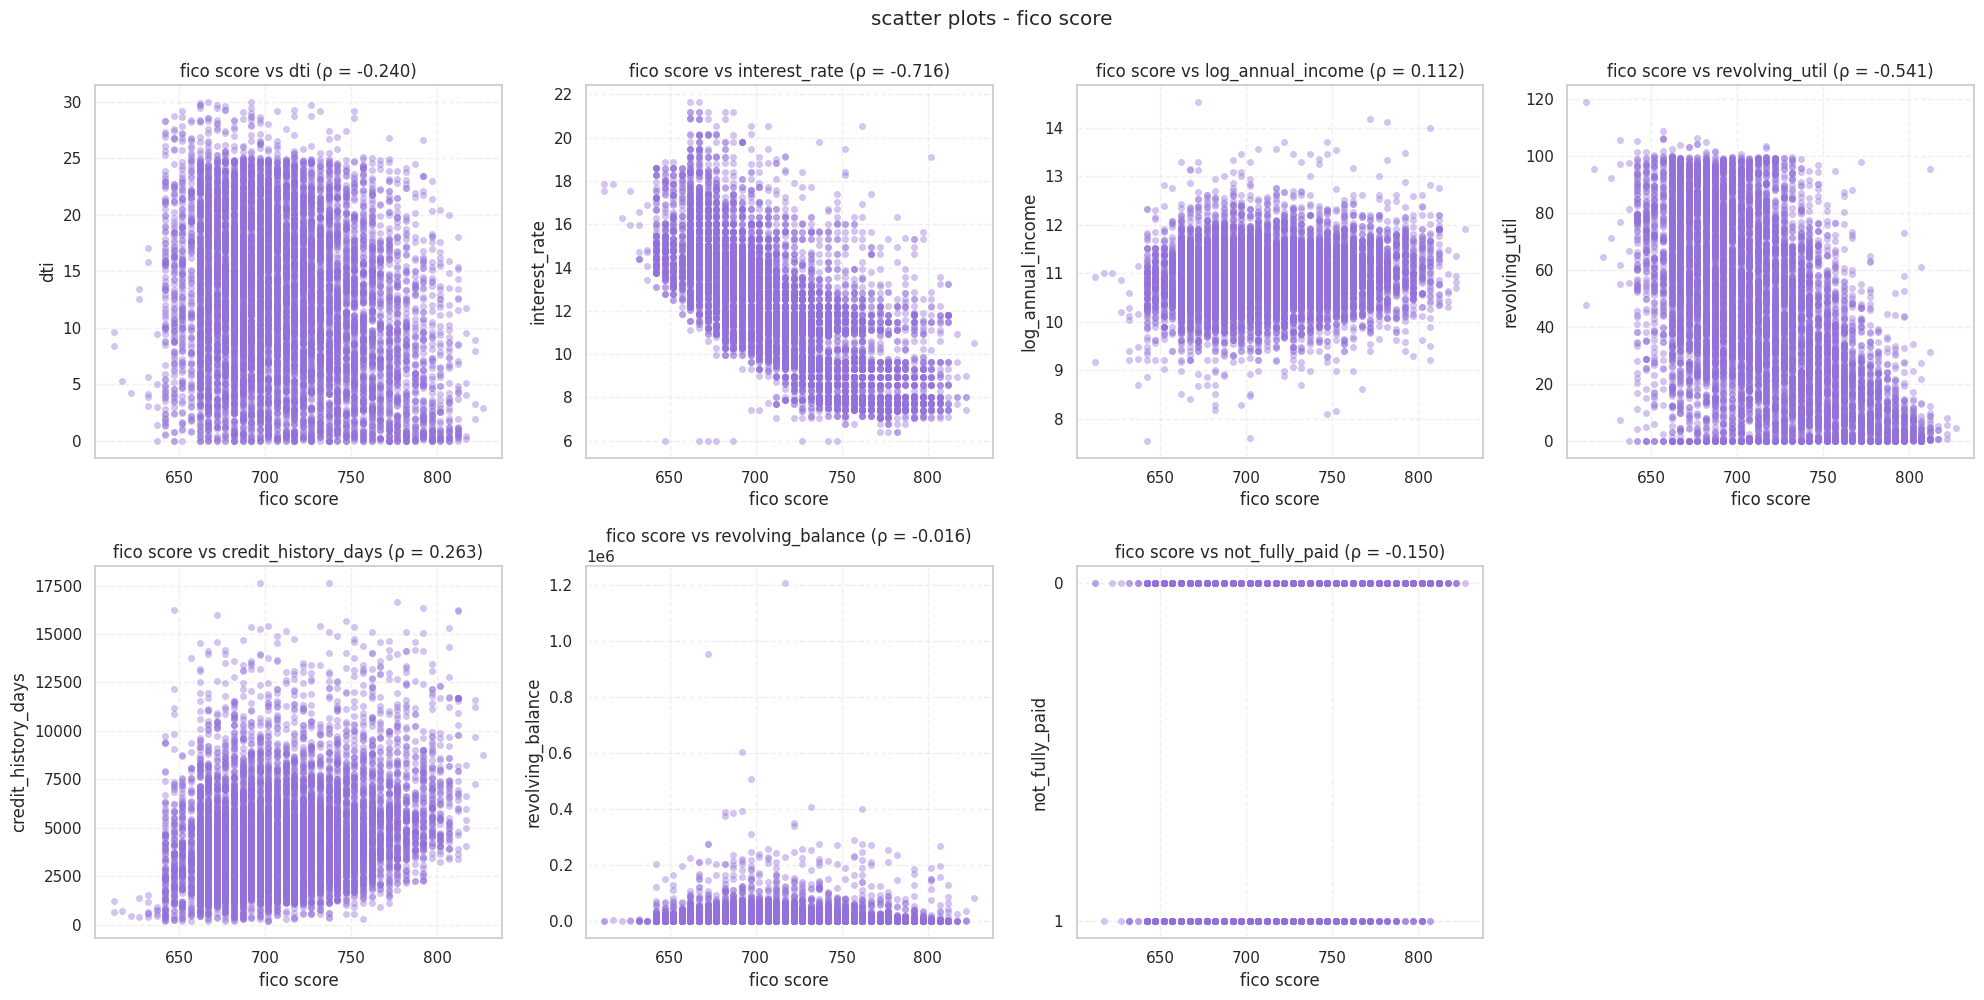

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, var in enumerate(fico_vars):
    sns.scatterplot(data=data, x='fico_score', y=var, alpha=0.4, s=20,
                   color='mediumpurple', edgecolor=None, ax=axes[idx])

    axes[idx].set_xlabel('fico score')
    axes[idx].set_ylabel(var)
    axes[idx].set_title(f'fico score vs {var} (ρ = {fico_correlations[var]:.3f})')
    axes[idx].grid(True, alpha=0.3, linestyle='--')

axes[7].axis('off')

plt.suptitle('scatter plots - fico score', y=0.998)
plt.tight_layout()
plt.show()

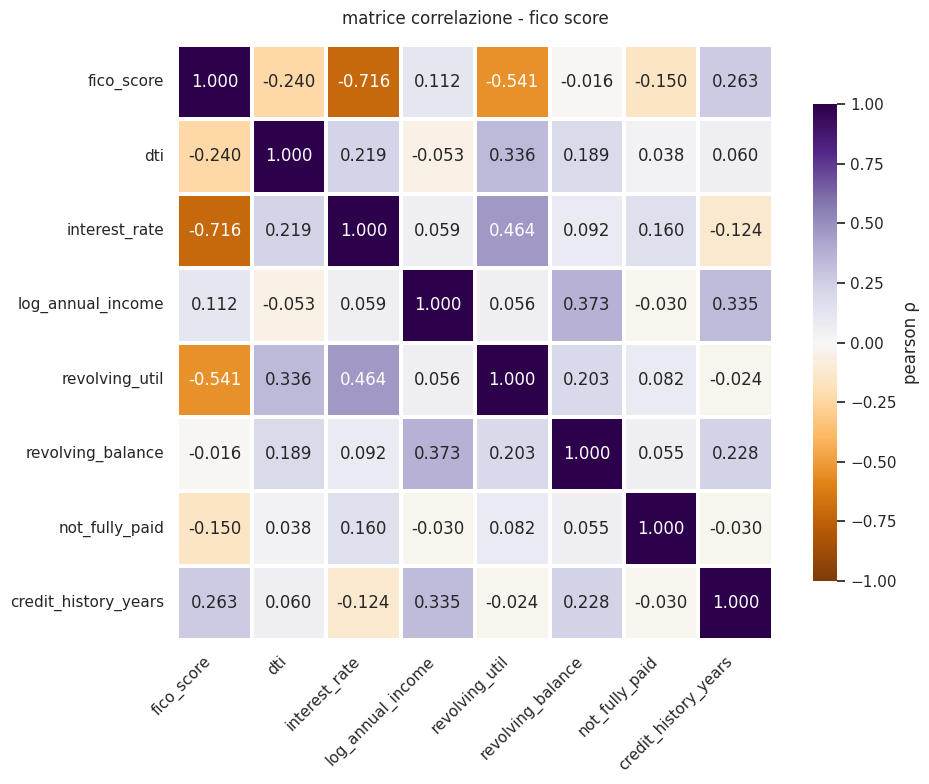

In [ ]:
correlation_vars_fico = ['fico_score', 'dti', 'interest_rate', 'log_annual_income',
                         'revolving_util', 'revolving_balance', 'not_fully_paid', 'credit_history_years']

corr_matrix_fico = data[correlation_vars_fico].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix_fico, annot=True, fmt='.3f', cmap='PuOr', center=0,
            square=True, linewidths=1.5, cbar_kws={"shrink": 0.8, "label": "pearson ρ"},
            vmin=-1, vmax=1, ax=ax)
plt.title('matrice correlazione - fico score', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.2 Distribuzioni Condizionate del FICO Score

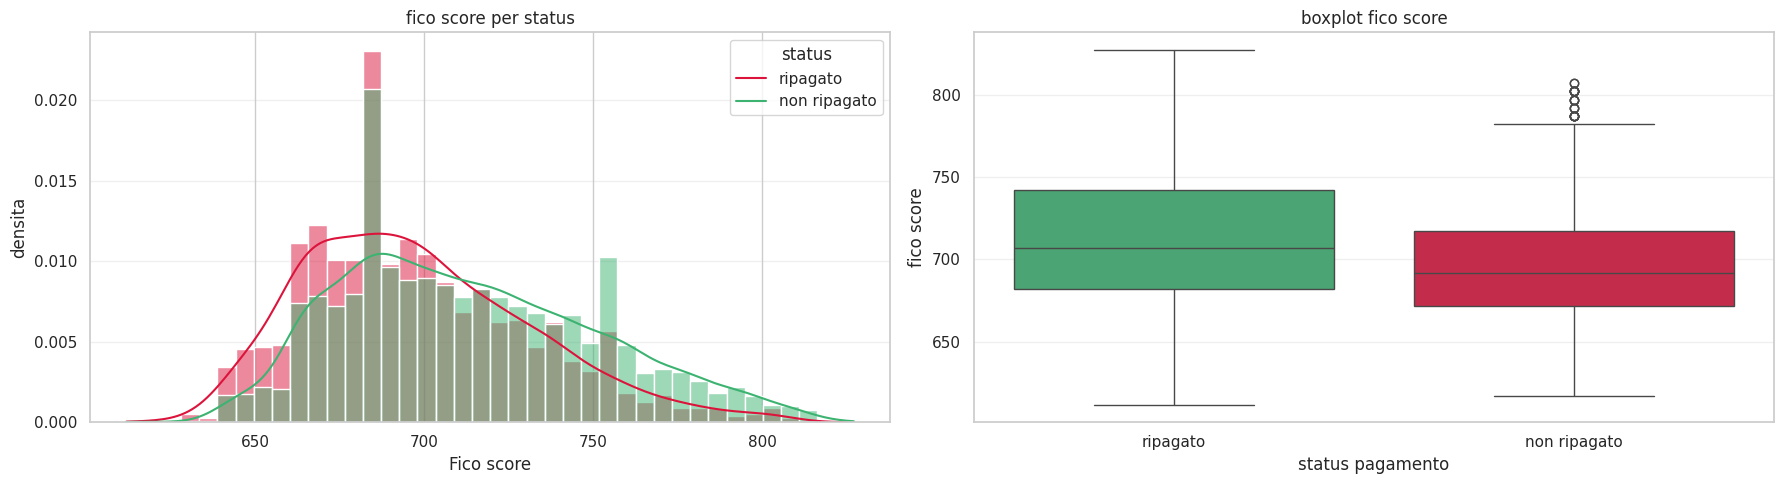

statistiche fico score per status pagamento:

non ripagato:
  media: 713.31
  mediana: 707.00
  std: 38.20

non ripagato:
  media: 697.82
  mediana: 692.00
  std: 33.64


In [ ]:
color_palette ={'0': 'mediumseagreen', '1': 'crimson'}

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data=data, x='fico_score', hue='not_fully_paid', bins=40, kde=True,
             palette=color_palette, alpha=0.5,
             ax=axes[0], stat='density', common_norm=False)
axes[0].set_xlabel('Fico score')
axes[0].set_ylabel('densita')
axes[0].set_title('fico score per status')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(labels=['ripagato', 'non ripagato'], title='status')
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(data=data, x='not_fully_paid', y='fico_score',
           palette=color_palette, ax=axes[1], hue='not_fully_paid', legend=False)
axes[1].set_xlabel('status pagamento')
axes[1].set_ylabel('fico score')
axes[1].set_title('boxplot fico score')
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['ripagato', 'non ripagato'])
axes[1].grid(True, alpha=0.3, axis='y')



plt.tight_layout()
plt.show()

print("statistiche fico score per status pagamento:")
print("="*50)

for status in ['0', '1']:
    fico_group = data[data['not_fully_paid'] == status]['fico_score']
    status_name = "ripagato" if status == 0 else "non ripagato"

    int_group = int_group.dropna()
    if not int_group.empty:
        print(f"\n{status_name}:")
        print(f"  media: {fico_group.mean():.2f}")
        print(f"  mediana: {fico_group.median():.2f}")
        print(f"  std: {fico_group.std():.2f}")
    else:
        print("\n{status_name}: Non sono stati trovati dati validi per questo status.")

**FICO SCORE e REVOLVING UTIL**

L’obiettivo dell’analisi FICO vs Revolving Util è capire come si combinano per indicare il rischio creditizio del cliente



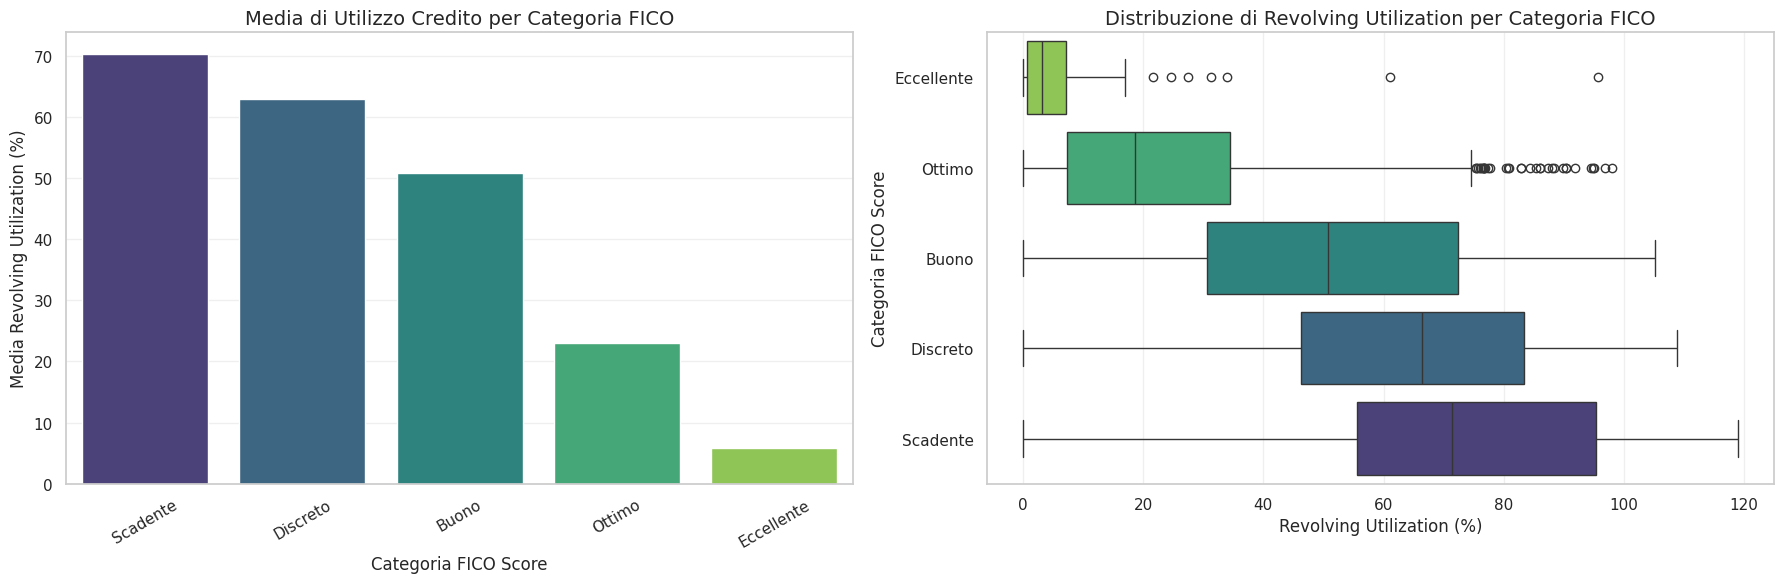


STATISTICHE DI REVOLVING UTILIZATION PER CATEGORIA FICO:

Categoria 'Scadente':
  Media:   70.34%
  Mediana: 71.40%
  Dev. Std.: 31.99%

Categoria 'Discreto':
  Media:   62.88%
  Mediana: 66.40%
  Dev. Std.: 25.63%

Categoria 'Buono':
  Media:   50.88%
  Mediana: 50.80%
  Dev. Std.: 26.91%

Categoria 'Ottimo':
  Media:   23.03%
  Mediana: 18.60%
  Dev. Std.: 19.59%

Categoria 'Eccellente':
  Media:   5.78%
  Mediana: 3.20%
  Dev. Std.: 10.76%


In [ ]:
data['fico_category'] = pd.cut(data['fico_score'], bins=[0, 640, 680, 740, 800, 850],
                              labels=['Scadente', 'Discreto', 'Buono', 'Ottimo', 'Eccellente'],
                              right=False, include_lowest=True)

FICO_CATEGORIES = ['Scadente', 'Discreto', 'Buono', 'Ottimo', 'Eccellente']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=data,
    x='fico_category',
    y='revolving_util',
    hue='fico_category',
    palette='viridis',
    order=FICO_CATEGORIES,
    ax=axes[0],
    errorbar=None,
    legend=False
)

axes[0].set_xlabel('Categoria FICO Score')
axes[0].set_ylabel('Media Revolving Utilization (%)')
axes[0].set_title('Media di Utilizzo Credito per Categoria FICO', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(
    data=data,
    x='revolving_util',
    y='fico_category',
    hue='fico_category',
    palette='viridis',
    order=FICO_CATEGORIES[::-1],
    ax=axes[1],
    legend=False
)

axes[1].set_xlabel('Revolving Utilization (%)')
axes[1].set_ylabel('Categoria FICO Score')
axes[1].set_title('Distribuzione di Revolving Utilization per Categoria FICO', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


print("\nSTATISTICHE DI REVOLVING UTILIZATION PER CATEGORIA FICO:")
print("="*60)

for category in FICO_CATEGORIES:
    util_group = data[data['fico_category'] == category]['revolving_util']

    if not util_group.empty:
        print(f"\nCategoria '{category}':")
        print(f"  Media:   {util_group.mean():.2f}%")
        print(f"  Mediana: {util_group.median():.2f}%")
        print(f"  Dev. Std.: {util_group.std():.2f}%")
    else:
        print(f"\nCategoria '{category}': Nessun dato trovato con questa etichetta.")

I risultati mostrano una relazione forte, monotona e inversa tra:
Qualità del credito (FICO Score)
e
Utilizzo del credito revolving (%)

👉 Chi ha un FICO scarso utilizza molto il credito disponibile.

👉 Chi ha un FICO eccellente mantiene i saldi revolving molto bassi.

La revolving utilization è fortemente associata al FICO Score.
Più è alto il FICO, più è bassa l’utilizzazione del credito.

Ma **QUANTO CAMBIA L'UTILIZZO DEL CREDITO AL VARIARE DEL PUNTEGGIO FICO SCORE?**

                            OLS Regression Results                            
Dep. Variable:         revolving_util   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     3928.
Date:                Mon, 22 Dec 2025   Prob (F-statistic):               0.00
Time:                        10:25:00   Log-Likelihood:                -43850.
No. Observations:                9504   AIC:                         8.770e+04
Df Residuals:                    9502   BIC:                         8.772e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        340.8919      4.698     72.558      0.0

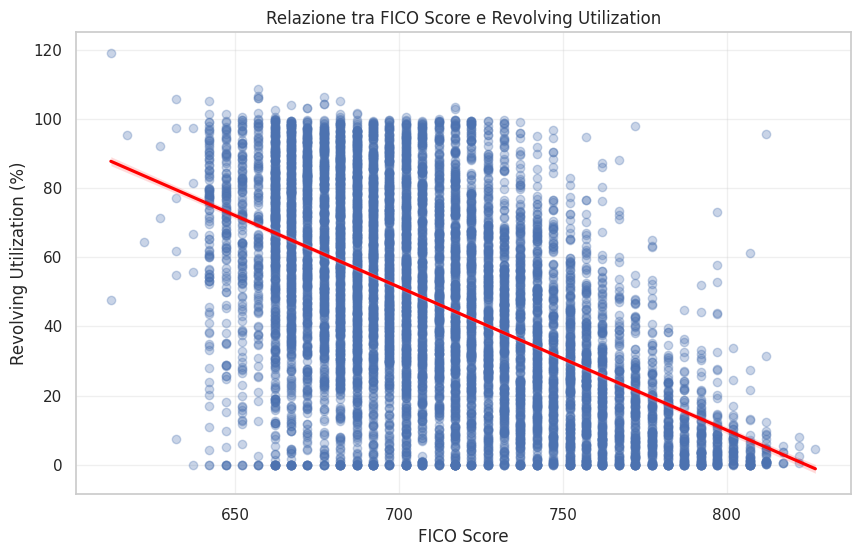

In [ ]:
df = data.dropna(subset=['fico_score', 'revolving_util']).copy()

X = df['fico_score']
X = sm.add_constant(X)

Y = df['revolving_util']
model = sm.OLS(Y,X).fit()
print(model.summary())

plt.figure(figsize=(10,6))
sns.regplot(data=df, x='fico_score', y='revolving_util',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title("Relazione tra FICO Score e Revolving Utilization")
plt.xlabel("FICO Score")
plt.ylabel("Revolving Utilization (%)")
plt.grid(True, alpha=0.3)
plt.show()





**coef = –0.4136**
Per ogni punto di aumento nel FICO score,
l’utilizzo revolving diminuisce in media di 0.4136 punti percentuali.

Più è basso il FICO, più il cliente usa tanto il credito revolving.
Più è alto il FICO, più l’utilizzo revolving tende a essere basso

**R-squared = 0.292**
Il FICO spiega circa il 29% della variabilità dell’utilizzo revolving.
Significa che è un predittore importante, ma non l’unico.

**P-value = 0.000**

Il coefficiente è altamente significativo.
→ La relazione è reale, non dovuta al caso.

**RISPOSTA ALLA DOMANDA**

**Un aumento del FICO score è associato a una riduzione significativa dell’utilizzo del credito revolving: in media, ogni punto aggiuntivo di FICO riduce l’utilizzo di circa 0,41 unità.**

Esiste relazione ed è fortissima
Relazione negativa: più FICO aumenta, meno revolving utilizzo.

 Ogni +1 punto FICO → –0.41% revolving
Ogni +100 punti FICO → –41% revolving


Clienti con FICO basso tendono ad avere utilizzo più alto ⇒ maggior rischio.

I prestiti concessi con FICO basso possono incorporare tassi più alti a causa del comportamento di revolving.

L’utilizzo revolving è uno degli elementi che causano FICO basso → relazione circolare.

Questo risultato è un pò implicito perchè a livello economico FICO score e utilizzo del credito sono concettualmente molto vicini.
In pratica, l’utilizzo del credito è una componente del FICO score!

Per capire per bene la relazione che intercorre tra queste due variabili è oppurtuno aggiungerne altre.




**L’effetto del FICO score sull’utilizzo del credito revolving rimane significativo controllando per reddito, indebitamento e storia creditizia del cliente?**

L’obiettivo dell’analisi è verificare se l’effetto del **FICO score** sull’utilizzo del credito revolving rimane statisticamente significativo una volta controllato per altre caratteristiche rilevanti del cliente, in particolare **reddito**, **livello di indebitamento (DTI)** , **storia creditizia** e **rata**.

                            OLS Regression Results                            
Dep. Variable:         revolving_util   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     1069.
Date:                Mon, 22 Dec 2025   Prob (F-statistic):               0.00
Time:                        10:25:00   Log-Likelihood:                -43120.
No. Observations:                9453   AIC:                         8.625e+04
Df Residuals:                    9447   BIC:                         8.629e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  276.1448 

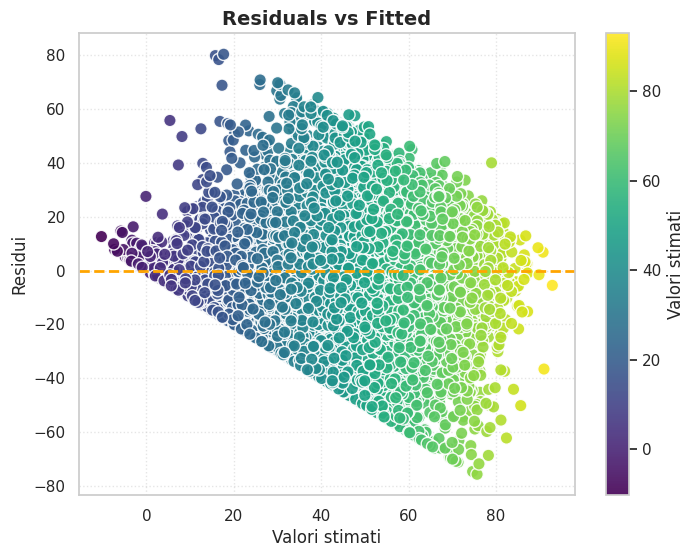

In [ ]:
df_main = data[
    [
        'customer_id',
        'revolving_util',
        'fico_score',
        'log_annual_income',
        'dti',
        'credit_history_years'
    ]
].copy()

data_installment = data_clean[['customer_id', 'installment']].copy()
df = df_main.merge(data_installment, on='customer_id', how='inner')
df = df.dropna()

# Variabile dipendente
y = df['revolving_util']

# Variabili indipendenti
X = df[
    [
        'fico_score',
        'log_annual_income',
        'dti',
        'installment',
        'credit_history_years'
    ]
]

# Aggiunta intercetta
X = sm.add_constant(X)
# Stima del modello
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())


plt.figure(figsize=(8,6))
scatter = plt.scatter(results.fittedvalues, results.resid,
                      c=results.fittedvalues, cmap='viridis', s=80, edgecolor='white', alpha=0.9)
plt.axhline(0, color='orange', linestyle='--', linewidth=2)
plt.xlabel("Valori stimati", fontsize=12)
plt.ylabel("Residui", fontsize=12)
plt.title("Residuals vs Fitted", fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Valori stimati')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()











**Risposta:** **Sì, l'effetto del FICO score rimane altamente significativo e robusto**

I risultati della regressione mostrano che il FICO score ha un effetto
**negativo e altamente significativo** sull’utilizzo del credito revolving
anche dopo aver controllato per le altre variabili esplicative e quindi va oltre la semplice ricchezza ($\text{log_annual_income}$) e il debito esistente ($\text{dti}$). Il risultato è che l'effetto è indipendente e significativo.. Il coefficiente associato al FICO score è pari a **-0.400** (p-value < 0.001), indicando che un aumento del punteggio di credito è associato a una riduzione dell’utilizzo del credito revolving, a parità di reddito, indebitamento, importo della rata e anzianità della storia creditizia.

Dal punto di vista economico, ciò implica che clienti con un punteggio di credito più elevato tendono a utilizzare una quota minore del credito disponibile, coerentemente con l’idea che soggetti più affidabili dal punto di vista creditizio abbiano un comportamento finanziario più prudente.

Il modello presenta un valore di **R² pari a 0.361**, suggerendo che circa il 36% della variabilità dell’utilizzo del credito revolving è spiegata dalle variabili incluse nella regressione.

I dati sono microeconomici (individui, famiglie, clienti), percui
considerata la natura microeconomica del fenomeno analizzato, tale valore è ragionevole.


Il grafico dei residui rispetto ai valori stimati mostra che i residui sono mediamente centrati intorno allo zero, suggerendo che la relazione lineare specificata dal modello è appropriata. Tuttavia, la dispersione dei residui **non è costante** lungo l’asse dei valori stimati.
 Questo pattern è un indicatore evidente di **eteroschedasticità** (ovvero di violazione dell’ipotesi di omoschedasticità degli errori richiesta dal modello OLS classico).

La presenza di eteroschedasticità è un fenomeno comune nei dati microeconomici, in particolare quando la variabile dipendente misura un’intensità o un utilizzo, come nel caso dell’utilizzo del credito revolving. Dal punto di vista economico, è plausibile che all’aumentare del livello di utilizzo aumenti anche la variabilità del comportamento individuale ovvero quando i clienti usano una percentuale maggiore del loro credito disponibile (alto $\text{revolving\_util}$), è naturale aspettarsi che le loro abitudini di spesa e rimborso diventino più imprevedibili.."
Pertanto, l’eteroschedasticità osservata può essere considerata un fenomeno normale e gestibile, che non compromette le conclusioni economiche dell’analisi.

L'obbiettivo ultimo è capire a quale cliente conviene fare prestiti al fine di capire con quale tipologia di cliente la banca ci guadagna di più

**Ragionando in termini bancari**
Predire se un cliente è rischioso o meno, così da decidere **a chi concedere il prestito e a quali condizioni**.


VALIDATION SET
Accuracy : 0.6283309957924264
Precision: 0.2378472222222222
Recall   : 0.6008771929824561
F1-score : 0.3407960199004975
ROC-AUC  : 0.6774961192630993

Confusion Matrix:
 [[759 439]
 [ 91 137]]


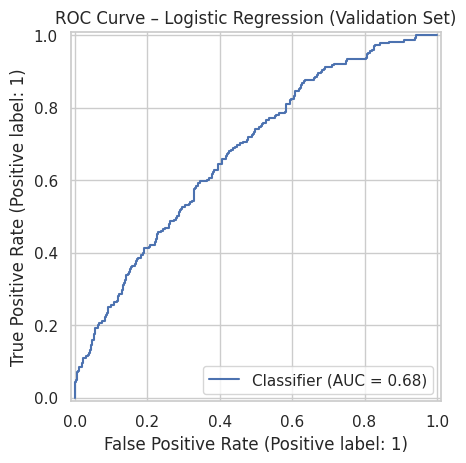

In [ ]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)
### 🔹 1. Target e feature set
df = data.copy()

#Target Binaria
y = df["not_fully_paid"].astype(int)



#Feature
X = df.drop(columns=["customer_id", "not_fully_paid"])

### 🔹 2. Feature numeriche e categoriche
numeric_features = [
    "interest_rate",
    "installment",
    "log_annual_income",
    "dti",
    "fico_score",
    "credit_history_years",
    "revolving_balance",
    "revolving_util",
    "inquiries_last_6m",
    "delinquencies_2y",
    "public_records"
]

categorical_features = [
    "purpose",
    "credit_policy"
]

### 🔹 3. Split Train / Validation / Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_temp
)

### 🔹 4. Pipeline: preprocessing + Logistic Regression
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

### 🔹 5. Training
model.fit(X_train, y_train)


### 🔹 6. Valutazione su Validation set
y_val_pred = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]

print("VALIDATION SET")
print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall   :", recall_score(y_val, y_val_pred))
print("F1-score :", f1_score(y_val, y_val_pred))
print("ROC-AUC  :", roc_auc_score(y_val, y_val_proba))

### 🔹 7. Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
print("\nConfusion Matrix:\n", cm)

### 🔹 8. ROC Curve (grafico CHIAVE)
RocCurveDisplay.from_predictions(y_val, y_val_proba)
plt.title("ROC Curve – Logistic Regression (Validation Set)")
plt.show()




In [ ]:
df["risk_flag_rule"] = (df["delinquencies_2y"] >= 1).astype(int)
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y, df["risk_flag_rule"]))
print(classification_report(y, df["risk_flag_rule"]))


[[7069  918]
 [1323  194]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      7987
           1       0.17      0.13      0.15      1517

    accuracy                           0.76      9504
   macro avg       0.51      0.51      0.51      9504
weighted avg       0.74      0.76      0.75      9504



In [ ]:
val_results = X_val.copy()

val_results["pd"] = model.predict_proba(X_val)[:, 1]  # probability of default
val_results["fico_score"] = X_val["fico_score"]
bins = [300, 580, 640, 700, 760, 850]
labels = ["Very Poor", "Poor", "Fair", "Good", "Very Good"]

val_results["fico_bucket"] = pd.cut(
    val_results["fico_score"],
    bins=bins,
    labels=labels,
    right=False
)
fico_risk = (
    val_results
    .groupby("fico_bucket", observed=True)["pd"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_pd", "count": "n_clients"})
)
print(fico_risk)




               avg_pd  n_clients
fico_bucket                     
Poor         0.655501          3
Fair         0.556073        620
Good         0.425600        609
Very Good    0.288010        194


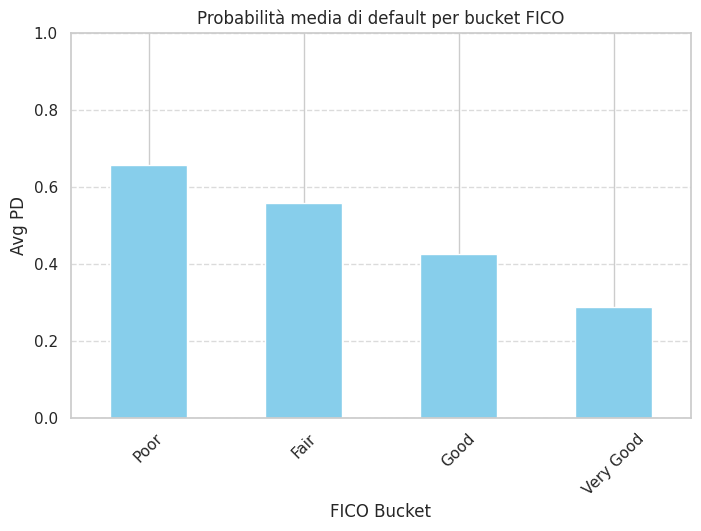

In [ ]:
import matplotlib.pyplot as plt

# Grafico a barre della probabilità media di default per bucket FICO
fico_risk.plot(kind='bar', y='avg_pd', legend=False, color='skyblue', figsize=(8,5))

plt.title('Probabilità media di default per bucket FICO')
plt.ylabel('Avg PD')
plt.xlabel('FICO Bucket')
plt.xticks(rotation=45)
plt.ylim(0, 1)  # la probabilità è tra 0 e 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


"Costruiamo" un **MOTORE DI VALUTAZIONE DEL CREDITO** ovvero:passiamo dei dati per ottenere una strategia decisionale a livello bancario

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# --- (Il caricamento dei dati e lo split rimangono invariati) ---
X_cols = ['fico_score', 'log_annual_income', 'dti']
y_col = 'delinquencies_2y'

# --- 3. SPLIT DEL DATASET (La parte che mancava!) ---
# Dividiamo in 60% Train, 20% Validation, 20% Test
train_val, test = train_test_split(df, test_size=0.2, random_state=42)
train, val = train_test_split(train_val, test_size=0.25, random_state=42)

# 3. Allenamento Regressore
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(train[X_cols], train[y_col])
#Il RandomForestRegressor impara a riconoscere quali caratteristiche dei clienti (reddito, debito, ecc.)
#portano a commettere insolvenze (delinquencies_2y). Non predice solo "sì/no", ma un valore numerico.

# 4. Predizione sul Validation Set
val['pred_delinquencies'] = model.predict(val[X_cols])
#Usiamo il set di Validation per simulare come il modello
#si comporterebbe con clienti nuovi che non ha mai visto.

# 5. Analisi per Fasce FICO e Rischio
bins = [0, 580, 670, 740, 800, 850]
labels = ['Pessimo', 'Scarso', 'Buono', 'Ottimo', 'Eccellente']
val['fico_range'] = pd.cut(val['fico_score'], bins=bins, labels=labels)
#ci aspettiamo che chi ha uno score "Eccellente" abbia predizioni di rischio molto basse.

# Soglia decisione
threshold = 0.5
val['is_risky'] = val['pred_delinquencies'].apply(lambda x: 'RISCHIOSO' if x > threshold else 'NON RISCHIOSO')
#Imponiamo una Soglia (0.5). Se il modello predice che un cliente avrà più di 0.5 insolvenze, lo etichettiamo come "RISCHIOSO" e gli neghiamo il prestito.

# 6. Aggregazione e trasformazione in Percentuale
analysis = val.groupby('fico_range', observed=False).agg({
    'pred_delinquencies': 'mean',
    'is_risky': lambda x: (x == 'NON RISCHIOSO').sum() / len(x) if len(x) > 0 else 0
}).rename(columns={
    'pred_delinquencies': ' |Media Insolvenze Predette| ',
    'is_risky': ' |Clienti Approvabili|'
})

# Riempimento NaN e conversione finale in percentuale per la visualizzazione
analysis = analysis.fillna(0)

# Moltiplichiamo per 100 per avere il valore percentuale intero
analysis_pct = analysis * 100

# Visualizzazione formattata
print("Analisi del Rischio per Fascia FICO:")
print(analysis_pct.round(2).astype(str) + '%')

Analisi del Rischio per Fascia FICO:
           |Media Insolvenze Predette|  |Clienti Approvabili|
fico_range                                                   
Pessimo                            0.0%                  0.0%
Scarso                           38.78%                72.03%
Buono                            17.09%                93.93%
Ottimo                            3.19%                99.75%
Eccellente                        1.03%                100.0%


**Scarso (38.78%)** Rischio alto. Qusi 4 clienti su 10 avranno problemi nei prossimi 2 anni.

**Ottimo/Eccellente (1.03% - 3.19%)** Qui il rischio è praticamente nullo. Sono i clienti ideali.

Il modello è il risultato della regola "*Presto soldi solo se il rischio predetto è <0.5*"

Si nota peò che nella fascia **Scarso** nonostante vi è un rischio alto, il modello approva 72.03%. Questo vale a dire che il regressore riesce a distinguere un gruppo di persone **(72%)** che ritiene "abbastanza sicure" e ritiene estremamente pericolose  solo il 28%.

Questo suggerisce che:
*  O i pochi che scarti sono "disastrosi" (es. predizione 0.9).
*  O la soglia di 0.5 è troppo permissiva per questa fascia.




"Puliamo" il portafoglio presiti in modo da **restringere la soglia solo per la fascia "Scarso" per vedere quanti ne rimarrebbero approvabili e a quanto scenderebbe il rischio medio di quel gruppo**

In [ ]:
# 1. Definiamo la funzione per la soglia variabile
def apply_smart_threshold(row):
    # Se il cliente è nella fascia "Scarso", la soglia è 0.2 (molto selettiva)
    if row['fico_range'] == 'Scarso':
        limit = 0.2
    else:
        # Per le altre fasce teniamo 0.5
        limit = 0.5

    return 'APPROVATO' if row['pred_delinquencies'] <= limit else 'RIFIUTATO'

# 2. Applichiamo la nuova regola al set di Validation
val['smart_decision'] = val.apply(apply_smart_threshold, axis=1)

# 3. Creiamo la nuova tabella di analisi
analysis_smart = val.groupby('fico_range', observed=False).agg({
    'pred_delinquencies': 'mean',
    'smart_decision': lambda x: (x == 'APPROVATO').sum() / len(x) if len(x) > 0 else 0
}).rename(columns={
    'pred_delinquencies': ' |Media Insolvenze Predette| ',
    'smart_decision': '|Clienti Approvabili| '
})

# 4. Formattazione e visualizzazione
analysis_smart_pct = (analysis_smart.fillna(0) * 100).round(2)

print("Analisi con SOGLIA RESTRITTIVA (0.2 solo per Scarso):")
print(analysis_smart_pct.astype(str) + '%')

Analisi con SOGLIA RESTRITTIVA (0.2 solo per Scarso):
            |Media Insolvenze Predette|  |Clienti Approvabili| 
fico_range                                                     
Pessimo                             0.0%                   0.0%
Scarso                            38.78%                 31.47%
Buono                             17.09%                 93.93%
Ottimo                             3.19%                 99.75%
Eccellente                         1.03%                 100.0%


I dati mostrano esattamente quello che cercavamo.


*   **Prima (Soglia 0.5) :** Clienti "scarso" approvabili 72.03%
*   **Ora (Soglia 0.2) :** Clienti "scarso" approvabili 31.47%.

Vengono rimossi il 40% di clienti "dubbi" anche se la media della fascia rimane il 38.78% (perchè dipende dai dati totali), l'esposizione reale è crollata.

A livello bancario, questo approccio serve a non perdere i clienti buoni che hanno avuto piccoli problemi in passato. Invece di dire "No" a tutti quelli con FICO Scarso, vengono accettati solo i migliori tra quelli che hanno lo score Scarso"



Adesso applichiamo al Test Set una "strategia finale" (soglia 0.2 per gli Scarsi, 0.5 per gli altri).

In [ ]:
# 1. Predizione sul TEST SET (Dati mai visti)
test['pred_delinquencies'] = model.predict(test[X_cols])

# 2. Creazione fasce FICO anche sul Test Set
test['fico_range'] = pd.cut(test['fico_score'], bins=bins, labels=labels)

# 3. Applicazione della Strategia Finale (Soglia differenziata)
def final_strategy(row):
    # Se Scarso, soglia 0.2. Altrimenti 0.5.
    threshold = 0.2 if row['fico_range'] == 'Scarso' else 0.5
    return 1 if row['pred_delinquencies'] <= threshold else 0

test['approved'] = test.apply(final_strategy, axis=1)

# 4. Calcolo delle performance REALI
# Uniamo la decisione con quello che è successo davvero (delinquencies_2y reale)
def calculate_real_outcome(row):
    if row['approved'] == 0:
        return '|Prestito Rifiutato|'
    else:
        # Se abbiamo prestato, verifichiamo il risultato reale
        return '|Successo (Pagato)|' if row['delinquencies_2y'] == 0 else '|DEFAULT (Perdita)|'

test['outcome'] = test.apply(calculate_real_outcome, axis=1)

# 5. Report Finale per il Management
final_report = test.groupby('fico_range', observed=False)['outcome'].value_counts(normalize=True).unstack().fillna(0)

# Convertiamo in percentuale per renderlo leggibile
final_report_pct = (final_report * 100).round(2)

print("--- VERDETTO FINALE SUL TEST SET (Mondo Reale) ---")
print(final_report_pct.astype(str) + '%')

--- VERDETTO FINALE SUL TEST SET (Mondo Reale) ---
outcome    |DEFAULT (Perdita)| |Prestito Rifiutato| |Successo (Pagato)|
fico_range                                                             
Pessimo                   0.0%                 0.0%                0.0%
Scarso                  10.53%               66.17%              23.31%
Buono                   10.57%                6.29%              83.14%
Ottimo                   2.19%                0.24%              97.57%
Eccellente                0.0%                 0.0%              100.0%


*   **Fascia Scarso**:
Il 23.31% dei clienti "accettati" ha pagato regolarmente e solo il 10.53% è andato a buon fine.
*  **Fascia Buono**: successo altissimo (83.14%).
Il default è al 10.57%.
* **Fascia Eccellente**: 100% di successo. Zero rischi.
* **Fascia Ottimo:** 97.57% di successo. Un default del 2% è fisiologico e non intacca minimamente i profitti.










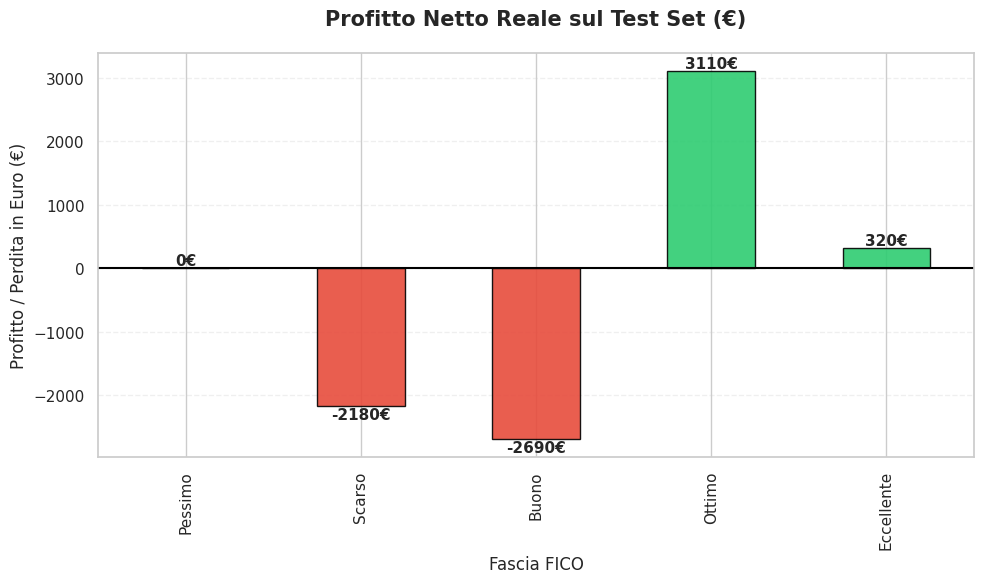

Profitti calcolati per fascia:
fico_range
Pessimo          0
Scarso       -2180
Buono        -2690
Ottimo        3110
Eccellente     320
Name: net_profit, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definiamo i pesi economici
INTEREST_PROFIT = 10   # Guadagno per ogni cliente che paga
DEFAULT_LOSS = -100    # Perdita per ogni cliente che va in default

# 2. Calcolo del profitto basato sui numeri (0 e 1) invece che sulle scritte
def calculate_money_final(row):
    # Se non abbiamo approvato il prestito (approved == 0), il profitto è 0
    if row['approved'] == 0:
        return 0
    # Se abbiamo approvato (approved == 1):
    else:
        # Se non c'è stata delinquency reale (delinquencies_2y == 0), guadagniamo
        if row['delinquencies_2y'] == 0:
            return INTEREST_PROFIT
        # Se c'è stata delinquency reale (> 0), perdiamo il capitale
        else:
            return DEFAULT_LOSS

# Applichiamo il calcolo al dataframe test
test['net_profit'] = test.apply(calculate_money_final, axis=1)

# 3. Raggruppiamo per fascia FICO e sommiamo i profitti
profit_analysis = test.groupby('fico_range', observed=False)['net_profit'].sum()

# 4. Creazione del grafico corretto
plt.figure(figsize=(10, 6))
# Colore rosso per le perdite, verde per i profitti
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in profit_analysis]

# Disegniamo le barre
ax = profit_analysis.plot(kind='bar', color=colors, edgecolor='black', alpha=0.9)

# Aggiungiamo titoli e scritte
plt.title('Profitto Netto Reale sul Test Set (€)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Profitto / Perdita in Euro (€)', fontsize=12)
plt.xlabel('Fascia FICO', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5) # Linea dello zero
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Inseriamo i valori numerici sopra (o sotto) ogni barra
for i, v in enumerate(profit_analysis):
    va_pos = 'bottom' if v >= 0 else 'top'
    offset = 5 if v >= 0 else -15
    plt.text(i, v + offset, f"{int(v)}€",
             ha='center', va=va_pos, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Debug: stampiamo i valori totali per essere sicuri che non siano zero
print("Profitti calcolati per fascia:")
print(profit_analysis)